<a href="https://colab.research.google.com/github/Habibaaboalhassan66/swimming-detection/blob/main/Phase2RiskDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!ls "/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models"

annotated_frames		pose_estimation_results_breaststroke.json
annotated_frames_new		pose_estimation_results_butterfly.json
biomechanical_features.csv	pose_estimation_results.json
biomechanical_features_new.csv	stroke_detection_cnn.h5
fl_global_model.h5		stroke_detection_results.json
hfl_cloud_model_BACKUP.keras	swimmer_train_mean.npy
hfl_swimmer_finetuned.keras	swimmer_train_std.npy
hfl_upper_body.keras		thesis_graphs
injury_detection_results.json	train_mean_BACKUP.npy
injury_report_fl.json		train_std_BACKUP.npy
pose_estimation_results1.json	visualizations


In [5]:
"""
injury_detection_fl_v2.py

Flat Federated Learning for swimmer-specific biomechanical risk classification.

Critical disclaimer:
This system identifies movement patterns that research has linked to higher injury rates
in swimmers. It does not diagnose injury — it flags patterns that warrant attention
from a coach or physiotherapist.

Purpose
-------
This script replaces the previous 7-local-node / 2-fog-node / 1-cloud hierarchical FL
setup with a simpler flat federated learning design:

    swimmer/client local nodes  --->  one global FedAvg server

It reads the Phase 1 output file:
    biomechanical_features.csv

and produces:
    fl_global_model.h5
    injury_report_fl.json
    fl_training_summary.csv
    per_sequence_predictions.csv

Important notes for your current CSV
------------------------------------
Your uploaded CSV contains:
    - left_elbow_angle
    - right_elbow_angle
    - keypoint coordinates for head, shoulders, elbows, and wrists
    - video_name
    - stroke
    - frame_risk_level

It does NOT contain:
    - left_shoulder_angle
    - right_shoulder_angle

Therefore, this script automatically calculates shoulder angles from keypoints:

    left_shoulder_angle  = angle(head -> left_shoulder -> left_elbow)
    right_shoulder_angle = angle(head -> right_shoulder -> right_elbow)

Default label mode
------------------
By default, this script uses your provided Safe/Risky video labels:

Butterfly:
    S09 = Safe
    S08 = Risky
    S07 = Safe

Breaststroke:
    S09 = Safe
    S08 = Risky
    S07 = Safe
    S06 = Risky
    S05 = Risky

You can switch to Phase 1 risk labels by setting:
    LABEL_MODE = "phase1_high_only"

where:
    high   -> 1
    medium -> 0
    low    -> 0
"""

# ============================================================
# 1. Imports
# ============================================================

import argparse
import json
import math
import os
import random
import re
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, optimizers, callbacks
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for this script. In Colab, run:\n"
        "!pip install -q tensorflow\n"
    ) from exc

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)


# ============================================================
# 2. Configuration
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Default Google Drive paths.
# You can override these from command line.
BASE_DIR = Path("/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters")
MODELS_DIR = BASE_DIR / "Models"
DEFAULT_INPUT_CSV = MODELS_DIR / "biomechanical_features.csv"
DEFAULT_OUTPUT_DIR = MODELS_DIR

# Main FL settings
SEQUENCE_LEN = 5
SEQUENCE_STEP = 1

FL_ROUNDS = 10
LOCAL_EPOCHS = 15
BATCH_SIZE = 4
LEARNING_RATE = 0.001

LOCAL_VAL_SIZE = 0.20
MIN_SAMPLES_FOR_VAL_SPLIT = 8
MIN_CLIENTS = 2

# Client grouping:
#   "swimmer_id" = one client per swimmer ID, e.g., S05, S06, S07, S08, S09
#   "video_name" = one client per video, e.g., breaststroke_front_S05
CLIENT_GROUPING = "swimmer_id"

# Label mode:
#   "coach_video_label" = use the Safe/Risky mapping below
#   "phase1_high_only" = high -> 1, medium/low -> 0
LABEL_MODE = "coach_video_label"

# Sequence label strategy when LABEL_MODE = "phase1_high_only":
#   "majority" = sequence is risky only if more than half the frames are high-risk
#   "any"      = sequence is risky if any frame is high-risk
#   "last"     = sequence label is the last frame label
PHASE1_SEQUENCE_LABEL_STRATEGY = "majority"

USE_CLASS_WEIGHTS = True

# Your provided video-level safety/risk labels.
# Values must be either "safe" or "risky".
VIDEO_STATUS_MAP = {
    # Butterfly
    "butterfly_front_S09": "safe",
    "butterfly_front_S08": "risky",
    "butterfly_front_S07": "safe",

    # Breaststroke
    "breaststroke_front_S09": "safe",   # Included although not present in the uploaded CSV.
    "breaststroke_front_S08": "risky",
    "breaststroke_front_S07": "safe",
    "breaststroke_front_S06": "risky",
    "breaststroke_front_S05": "risky",
}

# Required raw columns from Phase 1 CSV.
REQUIRED_COLUMNS = [
    "video_name",
    "frame_risk_level",
    "head_x", "head_y",
    "left_shoulder_x", "left_shoulder_y",
    "right_shoulder_x", "right_shoulder_y",
    "left_elbow_x", "left_elbow_y",
    "right_elbow_x", "right_elbow_y",
    "left_wrist_x", "left_wrist_y",
    "right_wrist_x", "right_wrist_y",
]

FEATURE_COLUMNS = [
    "left_shoulder_angle",
    "right_shoulder_angle",
    "left_elbow_angle",
    "right_elbow_angle",
]


# ============================================================
# 3. General utilities
# ============================================================

def set_reproducibility(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def json_safe(obj: Any) -> Any:
    """Convert numpy/tensorflow objects to JSON-safe Python objects."""
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        val = float(obj)
        if math.isnan(val) or math.isinf(val):
            return None
        return val
    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj
    return obj


def parse_frame_number(frame_name: Any, fallback: int) -> int:
    """
    Extracts a numeric frame order from values like 'frame_000123.jpg' or 'frame_123'.
    """
    if pd.isna(frame_name):
        return int(fallback)

    text = str(frame_name)
    numbers = re.findall(r"\d+", text)
    if not numbers:
        return int(fallback)
    return int(numbers[-1])


def extract_swimmer_id(video_name: str) -> str:
    """
    Extracts swimmer ID such as S05, S06, S07, S08, S09 from video_name.
    """
    match = re.search(r"S\d+", str(video_name), flags=re.IGNORECASE)
    if match:
        return match.group(0).upper()
    return str(video_name)


def angle_abc(ax: float, ay: float, bx: float, by: float, cx: float, cy: float, eps: float = 1e-8) -> float:
    """
    Calculates angle ABC in degrees where B is the vertex.
    """
    ba = np.array([ax - bx, ay - by], dtype=np.float64)
    bc = np.array([cx - bx, cy - by], dtype=np.float64)

    denom = (np.linalg.norm(ba) * np.linalg.norm(bc)) + eps
    cos_theta = float(np.dot(ba, bc) / denom)
    cos_theta = float(np.clip(cos_theta, -1.0, 1.0))

    return float(np.degrees(np.arccos(cos_theta)))


# ============================================================
# 4. Data loading and feature preparation
# ============================================================

def load_phase1_csv(input_csv: Path) -> pd.DataFrame:
    if not input_csv.exists():
        raise FileNotFoundError(
            f"Could not find input CSV:\n{input_csv}\n\n"
            "Make sure biomechanical_features.csv exists, or pass --input_csv."
        )

    df = pd.read_csv(input_csv)

    if df.empty:
        raise ValueError("The input CSV is empty.")

    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(
            "The CSV is missing required columns:\n"
            f"{missing}\n\n"
            f"Available columns:\n{list(df.columns)}"
        )

    return df


def add_or_fix_angles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensures the four model input angles exist:
        left_shoulder_angle
        right_shoulder_angle
        left_elbow_angle
        right_elbow_angle

    Shoulder angles are computed from keypoints if absent.
    Elbow angles are computed from keypoints if absent.
    """
    df = df.copy()

    if "left_shoulder_angle" not in df.columns:
        df["left_shoulder_angle"] = df.apply(
            lambda r: angle_abc(
                r["head_x"], r["head_y"],
                r["left_shoulder_x"], r["left_shoulder_y"],
                r["left_elbow_x"], r["left_elbow_y"],
            ),
            axis=1,
        )

    if "right_shoulder_angle" not in df.columns:
        df["right_shoulder_angle"] = df.apply(
            lambda r: angle_abc(
                r["head_x"], r["head_y"],
                r["right_shoulder_x"], r["right_shoulder_y"],
                r["right_elbow_x"], r["right_elbow_y"],
            ),
            axis=1,
        )

    if "left_elbow_angle" not in df.columns:
        df["left_elbow_angle"] = df.apply(
            lambda r: angle_abc(
                r["left_shoulder_x"], r["left_shoulder_y"],
                r["left_elbow_x"], r["left_elbow_y"],
                r["left_wrist_x"], r["left_wrist_y"],
            ),
            axis=1,
        )

    if "right_elbow_angle" not in df.columns:
        df["right_elbow_angle"] = df.apply(
            lambda r: angle_abc(
                r["right_shoulder_x"], r["right_shoulder_y"],
                r["right_elbow_x"], r["right_elbow_y"],
                r["right_wrist_x"], r["right_wrist_y"],
            ),
            axis=1,
        )

    return df


def attach_video_status_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds:
        swimmer_id
        video_status: safe/risky/unknown
        video_label: 0 for safe, 1 for risky
    """
    df = df.copy()
    df["swimmer_id"] = df["video_name"].apply(extract_swimmer_id)

    def get_status(video_name: str) -> str:
        video_name = str(video_name)
        return VIDEO_STATUS_MAP.get(video_name, "unknown").lower()

    df["video_status"] = df["video_name"].apply(get_status)

    unknown_videos = sorted(df.loc[df["video_status"] == "unknown", "video_name"].unique().tolist())
    if unknown_videos and LABEL_MODE == "coach_video_label":
        raise ValueError(
            "Some videos are not found in VIDEO_STATUS_MAP:\n"
            f"{unknown_videos}\n\n"
            "Add them to VIDEO_STATUS_MAP or switch LABEL_MODE to 'phase1_high_only'."
        )

    df["video_label"] = df["video_status"].map({"safe": 0, "risky": 1})
    return df


def add_phase1_frame_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds phase1_frame_label:
        high   -> 1
        medium -> 0
        low    -> 0
    """
    df = df.copy()
    risk = df["frame_risk_level"].astype(str).str.lower().str.strip()

    valid_values = {"low", "medium", "high"}
    unknown = sorted(set(risk.unique()) - valid_values)
    if unknown:
        raise ValueError(
            "frame_risk_level contains unexpected values:\n"
            f"{unknown}\n\n"
            "Expected only: low, medium, high."
        )

    df["phase1_frame_label"] = (risk == "high").astype(int)
    return df


def normalize_angle_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalizes angle features to [0, 1] by dividing by 180.
    """
    df = df.copy()

    for col in FEATURE_COLUMNS:
        if col not in df.columns:
            raise ValueError(f"Missing feature column after angle preparation: {col}")

        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].clip(lower=0, upper=180)
        df[col + "_norm"] = df[col] / 180.0

    return df


def prepare_dataframe(input_csv: Path) -> pd.DataFrame:
    df = load_phase1_csv(input_csv)
    df = add_or_fix_angles(df)
    df = attach_video_status_labels(df)
    df = add_phase1_frame_labels(df)
    df = normalize_angle_features(df)

    # Sort inside each video by real frame number, not just CSV row order.
    if "frame_name" in df.columns:
        df["_frame_order"] = [
            parse_frame_number(frame_name, fallback=i)
            for i, frame_name in enumerate(df["frame_name"].tolist())
        ]
    elif "frame_id" in df.columns:
        df["_frame_order"] = df["frame_id"].astype(int)
    else:
        df["_frame_order"] = np.arange(len(df))

    return df


# ============================================================
# 5. Sequence creation
# ============================================================

def get_client_id_for_row(row: pd.Series) -> str:
    if CLIENT_GROUPING == "swimmer_id":
        return str(row["swimmer_id"])
    if CLIENT_GROUPING == "video_name":
        return str(row["video_name"])

    raise ValueError(
        f"Unsupported CLIENT_GROUPING: {CLIENT_GROUPING}. "
        "Use 'swimmer_id' or 'video_name'."
    )


def sequence_label_from_phase1(frame_labels: np.ndarray) -> int:
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "majority":
        return int(np.mean(frame_labels) > 0.5)
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "any":
        return int(np.any(frame_labels == 1))
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "last":
        return int(frame_labels[-1])

    raise ValueError(
        f"Unsupported PHASE1_SEQUENCE_LABEL_STRATEGY: {PHASE1_SEQUENCE_LABEL_STRATEGY}"
    )


def make_sequences(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Creates fixed-length temporal sequences without crossing video boundaries.

    Returns:
        X: shape (num_sequences, SEQUENCE_LEN, 4)
        y: shape (num_sequences,)
        meta_df: sequence metadata
    """
    norm_cols = [col + "_norm" for col in FEATURE_COLUMNS]

    all_X = []
    all_y = []
    meta_rows = []

    for video_name, video_df in df.groupby("video_name"):
        video_df = video_df.sort_values("_frame_order").reset_index(drop=True)

        if len(video_df) < SEQUENCE_LEN:
            print(f"[WARN] Skipping {video_name}: only {len(video_df)} frames, need {SEQUENCE_LEN}.")
            continue

        features = video_df[norm_cols].to_numpy(dtype=np.float32)

        if LABEL_MODE == "coach_video_label":
            video_labels = video_df["video_label"].to_numpy()
            if np.any(pd.isna(video_labels)):
                raise ValueError(f"Missing coach/video label for video: {video_name}")
            frame_labels = video_labels.astype(int)
        elif LABEL_MODE == "phase1_high_only":
            frame_labels = video_df["phase1_frame_label"].to_numpy(dtype=int)
        else:
            raise ValueError(
                f"Unsupported LABEL_MODE: {LABEL_MODE}. "
                "Use 'coach_video_label' or 'phase1_high_only'."
            )

        for start in range(0, len(video_df) - SEQUENCE_LEN + 1, SEQUENCE_STEP):
            end = start + SEQUENCE_LEN

            X_seq = features[start:end]

            if np.isnan(X_seq).any():
                continue

            if LABEL_MODE == "coach_video_label":
                y_seq = int(frame_labels[start])
            else:
                y_seq = sequence_label_from_phase1(frame_labels[start:end])

            first_row = video_df.iloc[start]
            last_row = video_df.iloc[end - 1]

            client_id = get_client_id_for_row(first_row)

            all_X.append(X_seq)
            all_y.append(y_seq)

            meta_rows.append({
                "sequence_id": len(all_X) - 1,
                "client_id": client_id,
                "swimmer_id": str(first_row["swimmer_id"]),
                "video_name": str(video_name),
                "stroke": str(first_row["stroke"]) if "stroke" in video_df.columns else "",
                "video_status": str(first_row["video_status"]),
                "label": y_seq,
                "label_name": "risky" if y_seq == 1 else "safe_or_normal",
                "start_frame_order": int(first_row["_frame_order"]),
                "end_frame_order": int(last_row["_frame_order"]),
                "start_frame_name": str(first_row["frame_name"]) if "frame_name" in video_df.columns else "",
                "end_frame_name": str(last_row["frame_name"]) if "frame_name" in video_df.columns else "",
            })

    if not all_X:
        raise ValueError(
            "No sequences were created. Check SEQUENCE_LEN, input CSV, and feature columns."
        )

    X = np.asarray(all_X, dtype=np.float32)
    y = np.asarray(all_y, dtype=np.int32)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, meta_df


# ============================================================
# 6. Train/test split by client
# ============================================================

def split_by_client(
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    test_size: float = 0.20,
) -> Tuple[Dict[str, Dict[str, np.ndarray]], pd.DataFrame]:
    """
    Splits sequences into train/test sets inside each client.

    Returns:
        client_data[client_id] = {
            X_train, y_train, X_test, y_test, train_idx, test_idx
        }

        updated_meta_df with split column.
    """
    meta_df = meta_df.copy()
    meta_df["split"] = "unused"

    client_data = {}
    clients = sorted(meta_df["client_id"].unique().tolist())

    if len(clients) < MIN_CLIENTS:
        raise ValueError(
            f"Only {len(clients)} client(s) found. Need at least {MIN_CLIENTS} for FL.\n"
            f"Found clients: {clients}"
        )

    for client_id in clients:
        idx = meta_df.index[meta_df["client_id"] == client_id].to_numpy()
        y_client = y[idx]

        if len(idx) < MIN_SAMPLES_FOR_VAL_SPLIT:
            # Too few samples: train on all, no local test.
            train_idx = idx
            test_idx = np.array([], dtype=int)
        else:
            # Stratify only if the client has both classes.
            stratify = y_client if len(np.unique(y_client)) == 2 else None

            train_idx, test_idx = train_test_split(
                idx,
                test_size=test_size,
                random_state=SEED,
                shuffle=True,
                stratify=stratify,
            )

        meta_df.loc[train_idx, "split"] = "train"
        meta_df.loc[test_idx, "split"] = "test"

        client_data[client_id] = {
            "X_train": X[train_idx],
            "y_train": y[train_idx],
            "X_test": X[test_idx] if len(test_idx) else np.empty((0, SEQUENCE_LEN, len(FEATURE_COLUMNS)), dtype=np.float32),
            "y_test": y[test_idx] if len(test_idx) else np.empty((0,), dtype=np.int32),
            "train_idx": train_idx,
            "test_idx": test_idx,
        }

    return client_data, meta_df


# ============================================================
# 7. Model and FedAvg
# ============================================================

def build_model(input_shape: Tuple[int, int] = (SEQUENCE_LEN, len(FEATURE_COLUMNS))) -> tf.keras.Model:
    """
    Small 1D CNN suitable for short biomechanical angle sequences.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(32, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv1D(64, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.GlobalAveragePooling1D(),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model


def compute_class_weights(y_train_all: np.ndarray) -> Optional[Dict[int, float]]:
    if not USE_CLASS_WEIGHTS:
        return None

    counts = np.bincount(y_train_all.astype(int), minlength=2)
    total = int(np.sum(counts))

    if total == 0:
        return None

    weights = {}
    for cls in [0, 1]:
        if counts[cls] == 0:
            weights[cls] = 1.0
        else:
            weights[cls] = total / (2.0 * counts[cls])

    return weights


def fedavg_weighted(local_weights: List[List[np.ndarray]], local_sizes: List[int]) -> List[np.ndarray]:
    """
    Weighted FedAvg:
        global_weights = sum((n_i / N) * local_weights_i)
    """
    total_size = float(np.sum(local_sizes))
    if total_size <= 0:
        raise ValueError("Total local training size is zero; cannot run FedAvg.")

    new_weights = []
    for layer_weights in zip(*local_weights):
        weighted_layer = np.zeros_like(layer_weights[0])
        for weights_i, n_i in zip(layer_weights, local_sizes):
            weighted_layer += (n_i / total_size) * weights_i
        new_weights.append(weighted_layer)

    return new_weights


def predict_prob(model: tf.keras.Model, X: np.ndarray) -> np.ndarray:
    if len(X) == 0:
        return np.asarray([], dtype=np.float32)
    return model.predict(X, verbose=0).reshape(-1)


def calculate_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, Any]:
    if len(y_true) == 0:
        return {
            "n": 0,
            "accuracy": None,
            "precision": None,
            "recall": None,
            "f1": None,
            "auc": None,
            "confusion_matrix": None,
        }

    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )

    if len(np.unique(y_true)) == 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = None

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()

    return {
        "n": int(len(y_true)),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": None if auc is None else float(auc),
        "confusion_matrix": cm,
    }


def evaluate_global_model(
    model: tf.keras.Model,
    client_data: Dict[str, Dict[str, np.ndarray]],
    split: str = "test",
) -> Dict[str, Any]:
    """
    Evaluates the global model on either train or test data for all clients.
    """
    per_client = {}
    all_y = []
    all_prob = []

    for client_id, data in client_data.items():
        X_key = f"X_{split}"
        y_key = f"y_{split}"

        X_part = data[X_key]
        y_part = data[y_key]

        y_prob = predict_prob(model, X_part)
        metrics = calculate_metrics(y_part, y_prob)

        per_client[client_id] = metrics

        if len(y_part) > 0:
            all_y.append(y_part)
            all_prob.append(y_prob)

    if all_y:
        y_all = np.concatenate(all_y)
        prob_all = np.concatenate(all_prob)
        global_metrics = calculate_metrics(y_all, prob_all)
    else:
        global_metrics = calculate_metrics(np.asarray([]), np.asarray([]))

    return {
        "global": global_metrics,
        "per_client": per_client,
    }


def train_federated(
    X: np.ndarray,
    y: np.ndarray,
    client_data: Dict[str, Dict[str, np.ndarray]],
) -> Tuple[tf.keras.Model, List[Dict[str, Any]], Dict[str, Any]]:
    """
    Runs flat FedAvg across clients.
    """
    global_model = build_model(input_shape=(SEQUENCE_LEN, len(FEATURE_COLUMNS)))

    train_labels_all = []
    for data in client_data.values():
        if len(data["y_train"]) > 0:
            train_labels_all.append(data["y_train"])

    if not train_labels_all:
        raise ValueError("No training labels found.")

    y_train_all = np.concatenate(train_labels_all)
    class_weights = compute_class_weights(y_train_all)

    history_rows = []

    print("\n========== Federated Training Started ==========")
    print(f"Number of clients: {len(client_data)}")
    print(f"FL rounds: {FL_ROUNDS}")
    print(f"Local epochs per round: {LOCAL_EPOCHS}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Class weights: {class_weights}")
    print("================================================\n")

    for round_idx in range(1, FL_ROUNDS + 1):
        local_weights = []
        local_sizes = []

        print(f"\n--- FL Round {round_idx}/{FL_ROUNDS} ---")

        for client_id, data in client_data.items():
            X_train = data["X_train"]
            y_train = data["y_train"]

            if len(X_train) == 0:
                print(f"[WARN] Client {client_id} has no training data. Skipping.")
                continue

            local_model = build_model(input_shape=(SEQUENCE_LEN, len(FEATURE_COLUMNS)))
            local_model.set_weights(global_model.get_weights())

            early_stop = callbacks.EarlyStopping(
                monitor="loss",
                patience=3,
                restore_best_weights=True,
                verbose=0,
            )

            history = local_model.fit(
                X_train,
                y_train,
                epochs=LOCAL_EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=0,
                class_weight=class_weights,
                callbacks=[early_stop],
            )

            local_weights.append(local_model.get_weights())
            local_sizes.append(len(X_train))

            train_prob = predict_prob(local_model, X_train)
            local_train_metrics = calculate_metrics(y_train, train_prob)

            final_loss = float(history.history["loss"][-1])
            final_acc = float(history.history.get("accuracy", [np.nan])[-1])
            final_auc = float(history.history.get("auc", [np.nan])[-1])

            row = {
                "round": round_idx,
                "client_id": client_id,
                "train_sequences": int(len(X_train)),
                "local_loss": final_loss,
                "local_accuracy": final_acc,
                "local_auc": None if math.isnan(final_auc) else final_auc,
                "local_train_f1": local_train_metrics["f1"],
                "local_train_precision": local_train_metrics["precision"],
                "local_train_recall": local_train_metrics["recall"],
            }
            history_rows.append(row)

            print(
                f"Client {client_id}: "
                f"n={len(X_train)}, "
                f"loss={final_loss:.4f}, "
                f"acc={final_acc:.4f}"
            )

        if not local_weights:
            raise ValueError("No local models were trained in this round.")

        new_global_weights = fedavg_weighted(local_weights, local_sizes)
        global_model.set_weights(new_global_weights)

        train_eval = evaluate_global_model(global_model, client_data, split="train")
        test_eval = evaluate_global_model(global_model, client_data, split="test")

        print(
            f"Global train acc={train_eval['global']['accuracy']} | "
            f"train f1={train_eval['global']['f1']} | "
            f"test acc={test_eval['global']['accuracy']} | "
            f"test f1={test_eval['global']['f1']}"
        )

        # Add global metrics to all rows from this round.
        for row in history_rows:
            if row["round"] == round_idx:
                row["global_train_accuracy"] = train_eval["global"]["accuracy"]
                row["global_train_f1"] = train_eval["global"]["f1"]
                row["global_train_auc"] = train_eval["global"]["auc"]
                row["global_test_accuracy"] = test_eval["global"]["accuracy"]
                row["global_test_f1"] = test_eval["global"]["f1"]
                row["global_test_auc"] = test_eval["global"]["auc"]

    final_eval = {
        "train": evaluate_global_model(global_model, client_data, split="train"),
        "test": evaluate_global_model(global_model, client_data, split="test"),
    }

    return global_model, history_rows, final_eval


# ============================================================
# 8. Reporting
# ============================================================

def build_dataset_summary(df: pd.DataFrame, X: np.ndarray, y: np.ndarray, meta_df: pd.DataFrame) -> Dict[str, Any]:
    summary = {
        "input_frames": int(len(df)),
        "created_sequences": int(len(X)),
        "sequence_length": int(SEQUENCE_LEN),
        "sequence_step": int(SEQUENCE_STEP),
        "label_mode": LABEL_MODE,
        "client_grouping": CLIENT_GROUPING,
        "feature_columns": FEATURE_COLUMNS,
        "normalized_feature_columns": [c + "_norm" for c in FEATURE_COLUMNS],
        "class_distribution_sequences": {
            "safe_or_normal_0": int(np.sum(y == 0)),
            "risky_1": int(np.sum(y == 1)),
        },
        "videos_in_csv": sorted(df["video_name"].unique().tolist()),
        "videos_in_status_map_not_in_csv": sorted(set(VIDEO_STATUS_MAP.keys()) - set(df["video_name"].unique().tolist())),
        "per_video_frames": df["video_name"].value_counts().sort_index().to_dict(),
        "per_client_sequences": meta_df["client_id"].value_counts().sort_index().to_dict(),
        "per_client_label_counts": {},
        "per_video_label_counts": {},
    }

    for client_id, g in meta_df.groupby("client_id"):
        counts = g["label"].value_counts().sort_index().to_dict()
        summary["per_client_label_counts"][str(client_id)] = {
            "safe_or_normal_0": int(counts.get(0, 0)),
            "risky_1": int(counts.get(1, 0)),
        }

    for video_name, g in meta_df.groupby("video_name"):
        counts = g["label"].value_counts().sort_index().to_dict()
        summary["per_video_label_counts"][str(video_name)] = {
            "safe_or_normal_0": int(counts.get(0, 0)),
            "risky_1": int(counts.get(1, 0)),
        }

    return summary


def save_predictions(
    model: tf.keras.Model,
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    output_path: Path,
) -> pd.DataFrame:
    prob = predict_prob(model, X)
    pred = (prob >= 0.5).astype(int)

    pred_df = meta_df.copy()
    pred_df["true_label"] = y.astype(int)
    pred_df["predicted_probability_risky"] = prob
    pred_df["predicted_label"] = pred
    pred_df["predicted_label_name"] = np.where(pred == 1, "risky", "safe_or_normal")

    pred_df.to_csv(output_path, index=False)
    return pred_df


def build_report(
    df: pd.DataFrame,
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    history_rows: List[Dict[str, Any]],
    final_eval: Dict[str, Any],
    output_paths: Dict[str, str],
) -> Dict[str, Any]:

    report = {
        "critical_disclaimer": (
            "This system identifies movement patterns that research has linked to higher injury rates "
            "in swimmers. It does not diagnose injury — it flags patterns that warrant attention from "
            "a coach or physiotherapist."
        ),
        "architecture": {
            "type": "flat_federated_learning",
            "description": (
                "Each swimmer/client trains a local 1D CNN on local biomechanical angle sequences. "
                "A single global server aggregates local model weights using weighted FedAvg."
            ),
            "fedavg_formula": "global_weights = sum((n_i / N) * local_weights_i)",
            "previous_design_replaced": "7 local video nodes -> 2 fog nodes -> 1 cloud node",
            "new_design": f"{len(meta_df['client_id'].unique())} local client nodes -> 1 global server",
        },
        "dataset_summary": build_dataset_summary(df, X, y, meta_df),
        "model_config": {
            "sequence_len": SEQUENCE_LEN,
            "sequence_step": SEQUENCE_STEP,
            "input_features": FEATURE_COLUMNS,
            "normalization": "angles divided by 180",
            "model": "Conv1D(32) -> BatchNorm -> ReLU -> Conv1D(64) -> BatchNorm -> ReLU -> GlobalAveragePooling -> Dense(32) -> Dropout(0.3) -> Sigmoid",
            "fl_rounds": FL_ROUNDS,
            "local_epochs": LOCAL_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "class_weights_enabled": USE_CLASS_WEIGHTS,
        },
        "final_evaluation": final_eval,
        "training_history_rows": history_rows,
        "output_files": output_paths,
    }

    return json_safe(report)


# ============================================================
# 9. Main
# ============================================================

def main() -> None:
    global LABEL_MODE, CLIENT_GROUPING, FL_ROUNDS, LOCAL_EPOCHS, BATCH_SIZE

    parser = argparse.ArgumentParser(
        description="Flat Federated Learning for swimmer biomechanical injury-risk classification."
    )

    parser.add_argument(
        "--input_csv",
        type=str,
        default=str(DEFAULT_INPUT_CSV),
        help="Path to biomechanical_features.csv.",
    )

    parser.add_argument(
        "--output_dir",
        type=str,
        default=str(DEFAULT_OUTPUT_DIR),
        help="Directory where model/report files will be saved.",
    )

    parser.add_argument(
        "--label_mode",
        type=str,
        default=LABEL_MODE,
        choices=["coach_video_label", "phase1_high_only"],
        help="Which labels to use for training.",
    )

    parser.add_argument(
        "--client_grouping",
        type=str,
        default=CLIENT_GROUPING,
        choices=["swimmer_id", "video_name"],
        help="How to define FL clients.",
    )

    parser.add_argument(
        "--rounds",
        type=int,
        default=FL_ROUNDS,
        help="Number of FL rounds.",
    )

    parser.add_argument(
        "--epochs",
        type=int,
        default=LOCAL_EPOCHS,
        help="Local epochs per FL round.",
    )

    parser.add_argument(
        "--batch_size",
        type=int,
        default=BATCH_SIZE,
        help="Local batch size.",
    )

    args, unknown = parser.parse_known_args()

    # Update globals from CLI arguments.
    LABEL_MODE = args.label_mode
    CLIENT_GROUPING = args.client_grouping
    FL_ROUNDS = args.rounds
    LOCAL_EPOCHS = args.epochs
    BATCH_SIZE = args.batch_size

    set_reproducibility(SEED)

    input_csv = Path(args.input_csv)
    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    global_model_path = output_dir / "fl_global_model.h5"
    report_json_path = output_dir / "injury_report_fl.json"
    training_summary_csv = output_dir / "fl_training_summary.csv"
    predictions_csv = output_dir / "per_sequence_predictions.csv"

    print("\n========== Phase 2: Flat Federated Learning v2 ==========")
    print(f"Input CSV:       {input_csv}")
    print(f"Output dir:      {output_dir}")
    print(f"Label mode:      {LABEL_MODE}")
    print(f"Client grouping: {CLIENT_GROUPING}")
    print("=========================================================\n")

    df = prepare_dataframe(input_csv)

    print("CSV loaded successfully.")
    print(f"Frames: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print(f"Videos found: {sorted(df['video_name'].unique().tolist())}")
    print(f"Swimmers found: {sorted(df['swimmer_id'].unique().tolist())}")

    X, y, meta_df = make_sequences(df)

    print("\nSequences created successfully.")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print("Sequence class distribution:")
    print(pd.Series(y).value_counts().rename(index={0: "safe_or_normal_0", 1: "risky_1"}))

    client_data, meta_df = split_by_client(X, y, meta_df)

    print("\nClient split summary:")
    for client_id, data in client_data.items():
        print(
            f"Client {client_id}: "
            f"train={len(data['y_train'])}, "
            f"test={len(data['y_test'])}, "
            f"train labels={np.bincount(data['y_train'], minlength=2).tolist()}, "
            f"test labels={np.bincount(data['y_test'], minlength=2).tolist() if len(data['y_test']) else [0, 0]}"
        )

    global_model, history_rows, final_eval = train_federated(X, y, client_data)

    # Save final global model.
    global_model.save(global_model_path)
    print(f"\nSaved global model to: {global_model_path}")

    # Save training history.
    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(training_summary_csv, index=False)
    print(f"Saved training summary to: {training_summary_csv}")

    # Save predictions.
    pred_df = save_predictions(global_model, X, y, meta_df, predictions_csv)
    print(f"Saved sequence predictions to: {predictions_csv}")

    # Save JSON report.
    output_paths = {
        "global_model": str(global_model_path),
        "injury_report": str(report_json_path),
        "training_summary": str(training_summary_csv),
        "sequence_predictions": str(predictions_csv),
    }

    report = build_report(
        df=df,
        X=X,
        y=y,
        meta_df=meta_df,
        history_rows=history_rows,
        final_eval=final_eval,
        output_paths=output_paths,
    )

    with open(report_json_path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    print(f"Saved injury report to: {report_json_path}")

    print("\n========== Final Global Evaluation ==========")
    print(json.dumps(json_safe(final_eval), indent=2))
    print("============================================\n")


if __name__ == "__main__":
    main()



========== Phase 2: Flat Federated Learning v2 ==========
Input CSV:       /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/biomechanical_features.csv
Output dir:      /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models
Label mode:      coach_video_label
Client grouping: swimmer_id

CSV loaded successfully.
Frames: 264
Columns: 64
Videos found: ['breaststroke_front_S05', 'breaststroke_front_S06', 'breaststroke_front_S07', 'breaststroke_front_S08', 'butterfly_front_S07', 'butterfly_front_S08', 'butterfly_front_S09']
Swimmers found: ['S05', 'S06', 'S07', 'S08', 'S09']

Sequences created successfully.
X shape: (217, 5, 4)
y shape: (217,)
Sequence class distribution:
safe_or_normal_0    114
risky_1             103
Name: count, dtype: int64

Client split summary:
Client S05: train=7, test=2, train labels=[0, 7], test labels=[0, 2]
Client S06: train=19, test=5, train labels=[0, 19], test labels=[0, 5]
Client S07: train=51, test=13, train labels=[51, 0], test labels=[1

Client S08: n=56, loss=0.0026, acc=1.0000
Client S09: n=40, loss=0.0069, acc=1.0000
Global train acc=0.47398843930635837 | train f1=0.6431372549019608 | test acc=0.4772727272727273 | test f1=0.6461538461538462

--- FL Round 2/10 ---
Client S05: n=7, loss=0.0751, acc=1.0000
Client S06: n=19, loss=0.0212, acc=1.0000
Client S07: n=51, loss=0.0024, acc=1.0000
Client S08: n=56, loss=0.0072, acc=1.0000
Client S09: n=40, loss=0.0076, acc=1.0000
Global train acc=0.5491329479768786 | train f1=0.2777777777777778 | test acc=0.5681818181818182 | test f1=0.3448275862068966

--- FL Round 3/10 ---
Client S05: n=7, loss=0.0279, acc=1.0000
Client S06: n=19, loss=0.0114, acc=1.0000
Client S07: n=51, loss=0.0012, acc=1.0000
Client S08: n=56, loss=0.0041, acc=1.0000
Client S09: n=40, loss=0.0076, acc=1.0000
Global train acc=0.5317919075144508 | train f1=0.024096385542168676 | test acc=0.5227272727272727 | test f1=0.0

--- FL Round 4/10 ---
Client S05: n=7, loss=0.0277, acc=1.0000
Client S06: n=19, loss=0.


Saved global model to: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/fl_global_model.h5
Saved training summary to: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/fl_training_summary.csv
Saved sequence predictions to: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/per_sequence_predictions.csv
Saved injury report to: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/injury_report_fl.json

========== Final Global Evaluation ==========
{
  "train": {
    "global": {
      "n": 173,
      "accuracy": 0.5260115606936416,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "auc": 0.5103189493433395,
      "confusion_matrix": [
        [
          91,
          0
        ],
        [
          82,
          0
        ]
      ]
    },
    "per_client": {
      "S05": {
        "n": 7,
        "accuracy": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "auc": null,
        "confusion_matri

In [2]:
!pip install -q tensorflow scikit-learn pandas numpy

In [3]:
import os

csv_path = "/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/biomechanical_features_new.csv"

if os.path.exists(csv_path):
    print("CSV found:", csv_path)
else:
    print("CSV NOT found. Check the path.")

CSV found: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/biomechanical_features_new.csv


In [4]:
"""
injury_detection_fl_v2.py

Flat Federated Learning for swimmer-specific biomechanical risk classification.

Critical disclaimer:
This system identifies movement patterns that research has linked to higher injury rates
in swimmers. It does not diagnose injury — it flags patterns that warrant attention
from a coach or physiotherapist.

Purpose
-------
This script replaces the previous 7-local-node / 2-fog-node / 1-cloud hierarchical FL
setup with a simpler flat federated learning design:

    swimmer/client local nodes  --->  one global FedAvg server

It reads the Phase 1 output file:
    biomechanical_features.csv

and produces:
    fl_global_model.h5
    injury_report_fl.json
    fl_training_summary.csv
    per_sequence_predictions.csv

Important notes for your current CSV
------------------------------------
Your uploaded CSV contains:
    - left_elbow_angle
    - right_elbow_angle
    - keypoint coordinates for head, shoulders, elbows, and wrists
    - video_name
    - stroke
    - frame_risk_level

It does NOT contain:
    - left_shoulder_angle
    - right_shoulder_angle

Therefore, this script automatically calculates shoulder angles from keypoints:

    left_shoulder_angle  = angle(head -> left_shoulder -> left_elbow)
    right_shoulder_angle = angle(head -> right_shoulder -> right_elbow)

Default label mode
------------------
By default, this script uses your provided Safe/Risky video labels:

Butterfly:
    S09 = Safe
    S08 = Risky
    S07 = Safe

Breaststroke:
    S09 = Safe
    S08 = Risky
    S07 = Safe
    S06 = Risky
    S05 = Risky

You can switch to Phase 1 risk labels by setting:
    LABEL_MODE = "phase1_high_only"

where:
    high   -> 1
    medium -> 0
    low    -> 0
"""

# ============================================================
# 1. Imports
# ============================================================

import argparse
import json
import math
import os
import random
import re
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, optimizers, callbacks
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for this script. In Colab, run:\n"
        "!pip install -q tensorflow\n"
    ) from exc

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)


# ============================================================
# 2. Configuration
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Default Google Drive paths.
# You can override these from command line.
BASE_DIR = Path("/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters")
MODELS_DIR = BASE_DIR / "Models"
DEFAULT_INPUT_CSV = MODELS_DIR / "biomechanical_features.csv"
DEFAULT_OUTPUT_DIR = MODELS_DIR

# Main FL settings
SEQUENCE_LEN = 5
SEQUENCE_STEP = 1

FL_ROUNDS = 10
LOCAL_EPOCHS = 15
BATCH_SIZE = 4
LEARNING_RATE = 0.001

LOCAL_VAL_SIZE = 0.20
MIN_SAMPLES_FOR_VAL_SPLIT = 8
MIN_CLIENTS = 2

# Client grouping:
#   "swimmer_id" = one client per swimmer ID, e.g., S05, S06, S07, S08, S09
#   "video_name" = one client per video, e.g., breaststroke_front_S05
CLIENT_GROUPING = "swimmer_id"

# Label mode:
#   "coach_video_label" = use the Safe/Risky mapping below
#   "phase1_high_only" = high -> 1, medium/low -> 0
LABEL_MODE = "coach_video_label"

# Sequence label strategy when LABEL_MODE = "phase1_high_only":
#   "majority" = sequence is risky only if more than half the frames are high-risk
#   "any"      = sequence is risky if any frame is high-risk
#   "last"     = sequence label is the last frame label
PHASE1_SEQUENCE_LABEL_STRATEGY = "majority"

USE_CLASS_WEIGHTS = True

# Your provided video-level safety/risk labels.
# Values must be either "safe" or "risky".
VIDEO_STATUS_MAP = {
    # Butterfly
    "butterfly_front_S09": "safe",
    "butterfly_front_S08": "risky",
    "butterfly_front_S07": "safe",

    # Breaststroke
    "breaststroke_front_S09": "safe",   # Included although not present in the uploaded CSV.
    "breaststroke_front_S08": "risky",
    "breaststroke_front_S07": "safe",
    "breaststroke_front_S06": "risky",
    "breaststroke_front_S05": "risky",
}

# Required raw columns from Phase 1 CSV.
REQUIRED_COLUMNS = [
    "video_name",
    "frame_risk_level",
    "head_x", "head_y",
    "left_shoulder_x", "left_shoulder_y",
    "right_shoulder_x", "right_shoulder_y",
    "left_elbow_x", "left_elbow_y",
    "right_elbow_x", "right_elbow_y",
    "left_wrist_x", "left_wrist_y",
    "right_wrist_x", "right_wrist_y",
]

FEATURE_COLUMNS = [
    "left_shoulder_angle",
    "right_shoulder_angle",
    "left_elbow_angle",
    "right_elbow_angle",
]


# ============================================================
# 3. General utilities
# ============================================================

def set_reproducibility(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def json_safe(obj: Any) -> Any:
    """Convert numpy/tensorflow objects to JSON-safe Python objects."""
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        val = float(obj)
        if math.isnan(val) or math.isinf(val):
            return None
        return val
    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj
    return obj


def parse_frame_number(frame_name: Any, fallback: int) -> int:
    """
    Extracts a numeric frame order from values like 'frame_000123.jpg' or 'frame_123'.
    """
    if pd.isna(frame_name):
        return int(fallback)

    text = str(frame_name)
    numbers = re.findall(r"\d+", text)
    if not numbers:
        return int(fallback)
    return int(numbers[-1])


def extract_swimmer_id(video_name: str) -> str:
    """
    Extracts swimmer ID such as S05, S06, S07, S08, S09 from video_name.
    """
    match = re.search(r"S\d+", str(video_name), flags=re.IGNORECASE)
    if match:
        return match.group(0).upper()
    return str(video_name)


def angle_abc(ax: float, ay: float, bx: float, by: float, cx: float, cy: float, eps: float = 1e-8) -> float:
    """
    Calculates angle ABC in degrees where B is the vertex.
    """
    ba = np.array([ax - bx, ay - by], dtype=np.float64)
    bc = np.array([cx - bx, cy - by], dtype=np.float64)

    denom = (np.linalg.norm(ba) * np.linalg.norm(bc)) + eps
    cos_theta = float(np.dot(ba, bc) / denom)
    cos_theta = float(np.clip(cos_theta, -1.0, 1.0))

    return float(np.degrees(np.arccos(cos_theta)))


# ============================================================
# 4. Data loading and feature preparation
# ============================================================

def load_phase1_csv(input_csv: Path) -> pd.DataFrame:
    if not input_csv.exists():
        raise FileNotFoundError(
            f"Could not find input CSV:\n{input_csv}\n\n"
            "Make sure biomechanical_features.csv exists, or pass --input_csv."
        )

    df = pd.read_csv(input_csv)

    if df.empty:
        raise ValueError("The input CSV is empty.")

    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(
            "The CSV is missing required columns:\n"
            f"{missing}\n\n"
            f"Available columns:\n{list(df.columns)}"
        )

    return df


def add_or_fix_angles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensures the four model input angles exist:
        left_shoulder_angle
        right_shoulder_angle
        left_elbow_angle
        right_elbow_angle

    Shoulder angles are computed from keypoints if absent.
    Elbow angles are computed from keypoints if absent.
    """
    df = df.copy()

    if "left_shoulder_angle" not in df.columns:
        df["left_shoulder_angle"] = df.apply(
            lambda r: angle_abc(
                r["head_x"], r["head_y"],
                r["left_shoulder_x"], r["left_shoulder_y"],
                r["left_elbow_x"], r["left_elbow_y"],
            ),
            axis=1,
        )

    if "right_shoulder_angle" not in df.columns:
        df["right_shoulder_angle"] = df.apply(
            lambda r: angle_abc(
                r["head_x"], r["head_y"],
                r["right_shoulder_x"], r["right_shoulder_y"],
                r["right_elbow_x"], r["right_elbow_y"],
            ),
            axis=1,
        )

    if "left_elbow_angle" not in df.columns:
        df["left_elbow_angle"] = df.apply(
            lambda r: angle_abc(
                r["left_shoulder_x"], r["left_shoulder_y"],
                r["left_elbow_x"], r["left_elbow_y"],
                r["left_wrist_x"], r["left_wrist_y"],
            ),
            axis=1,
        )

    if "right_elbow_angle" not in df.columns:
        df["right_elbow_angle"] = df.apply(
            lambda r: angle_abc(
                r["right_shoulder_x"], r["right_shoulder_y"],
                r["right_elbow_x"], r["right_elbow_y"],
                r["right_wrist_x"], r["right_wrist_y"],
            ),
            axis=1,
        )

    return df


def attach_video_status_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds:
        swimmer_id
        video_status: safe/risky/unknown
        video_label: 0 for safe, 1 for risky
    """
    df = df.copy()
    df["swimmer_id"] = df["video_name"].apply(extract_swimmer_id)

    def get_status(video_name: str) -> str:
        video_name = str(video_name)
        return VIDEO_STATUS_MAP.get(video_name, "unknown").lower()

    df["video_status"] = df["video_name"].apply(get_status)

    unknown_videos = sorted(df.loc[df["video_status"] == "unknown", "video_name"].unique().tolist())
    if unknown_videos and LABEL_MODE == "coach_video_label":
        raise ValueError(
            "Some videos are not found in VIDEO_STATUS_MAP:\n"
            f"{unknown_videos}\n\n"
            "Add them to VIDEO_STATUS_MAP or switch LABEL_MODE to 'phase1_high_only'."
        )

    df["video_label"] = df["video_status"].map({"safe": 0, "risky": 1})
    return df


def add_phase1_frame_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds phase1_frame_label:
        high   -> 1
        medium -> 0
        low    -> 0
    """
    df = df.copy()
    risk = df["frame_risk_level"].astype(str).str.lower().str.strip()

    valid_values = {"low", "medium", "high"}
    unknown = sorted(set(risk.unique()) - valid_values)
    if unknown:
        raise ValueError(
            "frame_risk_level contains unexpected values:\n"
            f"{unknown}\n\n"
            "Expected only: low, medium, high."
        )

    df["phase1_frame_label"] = (risk == "high").astype(int)
    return df


def normalize_angle_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalizes angle features to [0, 1] by dividing by 180.
    """
    df = df.copy()

    for col in FEATURE_COLUMNS:
        if col not in df.columns:
            raise ValueError(f"Missing feature column after angle preparation: {col}")

        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].clip(lower=0, upper=180)
        df[col + "_norm"] = df[col] / 180.0

    return df


def prepare_dataframe(input_csv: Path) -> pd.DataFrame:
    df = load_phase1_csv(input_csv)
    df = add_or_fix_angles(df)
    df = attach_video_status_labels(df)
    df = add_phase1_frame_labels(df)
    df = normalize_angle_features(df)

    # Sort inside each video by real frame number, not just CSV row order.
    if "frame_name" in df.columns:
        df["_frame_order"] = [
            parse_frame_number(frame_name, fallback=i)
            for i, frame_name in enumerate(df["frame_name"].tolist())
        ]
    elif "frame_id" in df.columns:
        df["_frame_order"] = df["frame_id"].astype(int)
    else:
        df["_frame_order"] = np.arange(len(df))

    return df


# ============================================================
# 5. Sequence creation
# ============================================================

def get_client_id_for_row(row: pd.Series) -> str:
    if CLIENT_GROUPING == "swimmer_id":
        return str(row["swimmer_id"])
    if CLIENT_GROUPING == "video_name":
        return str(row["video_name"])

    raise ValueError(
        f"Unsupported CLIENT_GROUPING: {CLIENT_GROUPING}. "
        "Use 'swimmer_id' or 'video_name'."
    )


def sequence_label_from_phase1(frame_labels: np.ndarray) -> int:
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "majority":
        return int(np.mean(frame_labels) > 0.5)
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "any":
        return int(np.any(frame_labels == 1))
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "last":
        return int(frame_labels[-1])

    raise ValueError(
        f"Unsupported PHASE1_SEQUENCE_LABEL_STRATEGY: {PHASE1_SEQUENCE_LABEL_STRATEGY}"
    )


def make_sequences(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Creates fixed-length temporal sequences without crossing video boundaries.

    Returns:
        X: shape (num_sequences, SEQUENCE_LEN, 4)
        y: shape (num_sequences,)
        meta_df: sequence metadata
    """
    norm_cols = [col + "_norm" for col in FEATURE_COLUMNS]

    all_X = []
    all_y = []
    meta_rows = []

    for video_name, video_df in df.groupby("video_name"):
        video_df = video_df.sort_values("_frame_order").reset_index(drop=True)

        if len(video_df) < SEQUENCE_LEN:
            print(f"[WARN] Skipping {video_name}: only {len(video_df)} frames, need {SEQUENCE_LEN}.")
            continue

        features = video_df[norm_cols].to_numpy(dtype=np.float32)

        if LABEL_MODE == "coach_video_label":
            video_labels = video_df["video_label"].to_numpy()
            if np.any(pd.isna(video_labels)):
                raise ValueError(f"Missing coach/video label for video: {video_name}")
            frame_labels = video_labels.astype(int)
        elif LABEL_MODE == "phase1_high_only":
            frame_labels = video_df["phase1_frame_label"].to_numpy(dtype=int)
        else:
            raise ValueError(
                f"Unsupported LABEL_MODE: {LABEL_MODE}. "
                "Use 'coach_video_label' or 'phase1_high_only'."
            )

        for start in range(0, len(video_df) - SEQUENCE_LEN + 1, SEQUENCE_STEP):
            end = start + SEQUENCE_LEN

            X_seq = features[start:end]

            if np.isnan(X_seq).any():
                continue

            if LABEL_MODE == "coach_video_label":
                y_seq = int(frame_labels[start])
            else:
                y_seq = sequence_label_from_phase1(frame_labels[start:end])

            first_row = video_df.iloc[start]
            last_row = video_df.iloc[end - 1]

            client_id = get_client_id_for_row(first_row)

            all_X.append(X_seq)
            all_y.append(y_seq)

            meta_rows.append({
                "sequence_id": len(all_X) - 1,
                "client_id": client_id,
                "swimmer_id": str(first_row["swimmer_id"]),
                "video_name": str(video_name),
                "stroke": str(first_row["stroke"]) if "stroke" in video_df.columns else "",
                "video_status": str(first_row["video_status"]),
                "label": y_seq,
                "label_name": "risky" if y_seq == 1 else "safe_or_normal",
                "start_frame_order": int(first_row["_frame_order"]),
                "end_frame_order": int(last_row["_frame_order"]),
                "start_frame_name": str(first_row["frame_name"]) if "frame_name" in video_df.columns else "",
                "end_frame_name": str(last_row["frame_name"]) if "frame_name" in video_df.columns else "",
            })

    if not all_X:
        raise ValueError(
            "No sequences were created. Check SEQUENCE_LEN, input CSV, and feature columns."
        )

    X = np.asarray(all_X, dtype=np.float32)
    y = np.asarray(all_y, dtype=np.int32)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, meta_df


# ============================================================
# 6. Train/test split by client
# ============================================================

def split_by_client(
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    test_size: float = 0.20,
) -> Tuple[Dict[str, Dict[str, np.ndarray]], pd.DataFrame]:
    """
    Splits sequences into train/test sets inside each client.

    Returns:
        client_data[client_id] = {
            X_train, y_train, X_test, y_test, train_idx, test_idx
        }

        updated_meta_df with split column.
    """
    meta_df = meta_df.copy()
    meta_df["split"] = "unused"

    client_data = {}
    clients = sorted(meta_df["client_id"].unique().tolist())

    if len(clients) < MIN_CLIENTS:
        raise ValueError(
            f"Only {len(clients)} client(s) found. Need at least {MIN_CLIENTS} for FL.\n"
            f"Found clients: {clients}"
        )

    for client_id in clients:
        idx = meta_df.index[meta_df["client_id"] == client_id].to_numpy()
        y_client = y[idx]

        if len(idx) < MIN_SAMPLES_FOR_VAL_SPLIT:
            # Too few samples: train on all, no local test.
            train_idx = idx
            test_idx = np.array([], dtype=int)
        else:
            # Stratify only if the client has both classes.
            stratify = y_client if len(np.unique(y_client)) == 2 else None

            train_idx, test_idx = train_test_split(
                idx,
                test_size=test_size,
                random_state=SEED,
                shuffle=True,
                stratify=stratify,
            )

        meta_df.loc[train_idx, "split"] = "train"
        meta_df.loc[test_idx, "split"] = "test"

        client_data[client_id] = {
            "X_train": X[train_idx],
            "y_train": y[train_idx],
            "X_test": X[test_idx] if len(test_idx) else np.empty((0, SEQUENCE_LEN, len(FEATURE_COLUMNS)), dtype=np.float32),
            "y_test": y[test_idx] if len(test_idx) else np.empty((0,), dtype=np.int32),
            "train_idx": train_idx,
            "test_idx": test_idx,
        }

    return client_data, meta_df


# ============================================================
# 7. Model and FedAvg
# ============================================================

def build_model(input_shape: Tuple[int, int] = (SEQUENCE_LEN, len(FEATURE_COLUMNS))) -> tf.keras.Model:
    """
    Small 1D CNN suitable for short biomechanical angle sequences.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(32, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv1D(64, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.GlobalAveragePooling1D(),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model


def compute_class_weights(y_train_all: np.ndarray) -> Optional[Dict[int, float]]:
    if not USE_CLASS_WEIGHTS:
        return None

    counts = np.bincount(y_train_all.astype(int), minlength=2)
    total = int(np.sum(counts))

    if total == 0:
        return None

    weights = {}
    for cls in [0, 1]:
        if counts[cls] == 0:
            weights[cls] = 1.0
        else:
            weights[cls] = total / (2.0 * counts[cls])

    return weights


def fedavg_weighted(local_weights: List[List[np.ndarray]], local_sizes: List[int]) -> List[np.ndarray]:
    """
    Weighted FedAvg:
        global_weights = sum((n_i / N) * local_weights_i)
    """
    total_size = float(np.sum(local_sizes))
    if total_size <= 0:
        raise ValueError("Total local training size is zero; cannot run FedAvg.")

    new_weights = []
    for layer_weights in zip(*local_weights):
        weighted_layer = np.zeros_like(layer_weights[0])
        for weights_i, n_i in zip(layer_weights, local_sizes):
            weighted_layer += (n_i / total_size) * weights_i
        new_weights.append(weighted_layer)

    return new_weights


def predict_prob(model: tf.keras.Model, X: np.ndarray) -> np.ndarray:
    if len(X) == 0:
        return np.asarray([], dtype=np.float32)
    return model.predict(X, verbose=0).reshape(-1)


def calculate_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, Any]:
    if len(y_true) == 0:
        return {
            "n": 0,
            "accuracy": None,
            "precision": None,
            "recall": None,
            "f1": None,
            "auc": None,
            "confusion_matrix": None,
        }

    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )

    if len(np.unique(y_true)) == 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = None

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()

    return {
        "n": int(len(y_true)),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": None if auc is None else float(auc),
        "confusion_matrix": cm,
    }


def evaluate_global_model(
    model: tf.keras.Model,
    client_data: Dict[str, Dict[str, np.ndarray]],
    split: str = "test",
) -> Dict[str, Any]:
    """
    Evaluates the global model on either train or test data for all clients.
    """
    per_client = {}
    all_y = []
    all_prob = []

    for client_id, data in client_data.items():
        X_key = f"X_{split}"
        y_key = f"y_{split}"

        X_part = data[X_key]
        y_part = data[y_key]

        y_prob = predict_prob(model, X_part)
        metrics = calculate_metrics(y_part, y_prob)

        per_client[client_id] = metrics

        if len(y_part) > 0:
            all_y.append(y_part)
            all_prob.append(y_prob)

    if all_y:
        y_all = np.concatenate(all_y)
        prob_all = np.concatenate(all_prob)
        global_metrics = calculate_metrics(y_all, prob_all)
    else:
        global_metrics = calculate_metrics(np.asarray([]), np.asarray([]))

    return {
        "global": global_metrics,
        "per_client": per_client,
    }


def train_federated(
    X: np.ndarray,
    y: np.ndarray,
    client_data: Dict[str, Dict[str, np.ndarray]],
) -> Tuple[tf.keras.Model, List[Dict[str, Any]], Dict[str, Any]]:
    """
    Runs flat FedAvg across clients.
    """
    global_model = build_model(input_shape=(SEQUENCE_LEN, len(FEATURE_COLUMNS)))

    train_labels_all = []
    for data in client_data.values():
        if len(data["y_train"]) > 0:
            train_labels_all.append(data["y_train"])

    if not train_labels_all:
        raise ValueError("No training labels found.")

    y_train_all = np.concatenate(train_labels_all)
    class_weights = compute_class_weights(y_train_all)

    history_rows = []

    print("\n========== Federated Training Started ==========")
    print(f"Number of clients: {len(client_data)}")
    print(f"FL rounds: {FL_ROUNDS}")
    print(f"Local epochs per round: {LOCAL_EPOCHS}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Class weights: {class_weights}")
    print("================================================\n")

    for round_idx in range(1, FL_ROUNDS + 1):
        local_weights = []
        local_sizes = []

        print(f"\n--- FL Round {round_idx}/{FL_ROUNDS} ---")

        for client_id, data in client_data.items():
            X_train = data["X_train"]
            y_train = data["y_train"]

            if len(X_train) == 0:
                print(f"[WARN] Client {client_id} has no training data. Skipping.")
                continue

            local_model = build_model(input_shape=(SEQUENCE_LEN, len(FEATURE_COLUMNS)))
            local_model.set_weights(global_model.get_weights())

            early_stop = callbacks.EarlyStopping(
                monitor="loss",
                patience=3,
                restore_best_weights=True,
                verbose=0,
            )

            history = local_model.fit(
                X_train,
                y_train,
                epochs=LOCAL_EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=0,
                class_weight=class_weights,
                callbacks=[early_stop],
            )

            local_weights.append(local_model.get_weights())
            local_sizes.append(len(X_train))

            train_prob = predict_prob(local_model, X_train)
            local_train_metrics = calculate_metrics(y_train, train_prob)

            final_loss = float(history.history["loss"][-1])
            final_acc = float(history.history.get("accuracy", [np.nan])[-1])
            final_auc = float(history.history.get("auc", [np.nan])[-1])

            row = {
                "round": round_idx,
                "client_id": client_id,
                "train_sequences": int(len(X_train)),
                "local_loss": final_loss,
                "local_accuracy": final_acc,
                "local_auc": None if math.isnan(final_auc) else final_auc,
                "local_train_f1": local_train_metrics["f1"],
                "local_train_precision": local_train_metrics["precision"],
                "local_train_recall": local_train_metrics["recall"],
            }
            history_rows.append(row)

            print(
                f"Client {client_id}: "
                f"n={len(X_train)}, "
                f"loss={final_loss:.4f}, "
                f"acc={final_acc:.4f}"
            )

        if not local_weights:
            raise ValueError("No local models were trained in this round.")

        new_global_weights = fedavg_weighted(local_weights, local_sizes)
        global_model.set_weights(new_global_weights)

        train_eval = evaluate_global_model(global_model, client_data, split="train")
        test_eval = evaluate_global_model(global_model, client_data, split="test")

        print(
            f"Global train acc={train_eval['global']['accuracy']} | "
            f"train f1={train_eval['global']['f1']} | "
            f"test acc={test_eval['global']['accuracy']} | "
            f"test f1={test_eval['global']['f1']}"
        )

        # Add global metrics to all rows from this round.
        for row in history_rows:
            if row["round"] == round_idx:
                row["global_train_accuracy"] = train_eval["global"]["accuracy"]
                row["global_train_f1"] = train_eval["global"]["f1"]
                row["global_train_auc"] = train_eval["global"]["auc"]
                row["global_test_accuracy"] = test_eval["global"]["accuracy"]
                row["global_test_f1"] = test_eval["global"]["f1"]
                row["global_test_auc"] = test_eval["global"]["auc"]

    final_eval = {
        "train": evaluate_global_model(global_model, client_data, split="train"),
        "test": evaluate_global_model(global_model, client_data, split="test"),
    }

    return global_model, history_rows, final_eval


# ============================================================
# 8. Reporting
# ============================================================

def build_dataset_summary(df: pd.DataFrame, X: np.ndarray, y: np.ndarray, meta_df: pd.DataFrame) -> Dict[str, Any]:
    summary = {
        "input_frames": int(len(df)),
        "created_sequences": int(len(X)),
        "sequence_length": int(SEQUENCE_LEN),
        "sequence_step": int(SEQUENCE_STEP),
        "label_mode": LABEL_MODE,
        "client_grouping": CLIENT_GROUPING,
        "feature_columns": FEATURE_COLUMNS,
        "normalized_feature_columns": [c + "_norm" for c in FEATURE_COLUMNS],
        "class_distribution_sequences": {
            "safe_or_normal_0": int(np.sum(y == 0)),
            "risky_1": int(np.sum(y == 1)),
        },
        "videos_in_csv": sorted(df["video_name"].unique().tolist()),
        "videos_in_status_map_not_in_csv": sorted(set(VIDEO_STATUS_MAP.keys()) - set(df["video_name"].unique().tolist())),
        "per_video_frames": df["video_name"].value_counts().sort_index().to_dict(),
        "per_client_sequences": meta_df["client_id"].value_counts().sort_index().to_dict(),
        "per_client_label_counts": {},
        "per_video_label_counts": {},
    }

    for client_id, g in meta_df.groupby("client_id"):
        counts = g["label"].value_counts().sort_index().to_dict()
        summary["per_client_label_counts"][str(client_id)] = {
            "safe_or_normal_0": int(counts.get(0, 0)),
            "risky_1": int(counts.get(1, 0)),
        }

    for video_name, g in meta_df.groupby("video_name"):
        counts = g["label"].value_counts().sort_index().to_dict()
        summary["per_video_label_counts"][str(video_name)] = {
            "safe_or_normal_0": int(counts.get(0, 0)),
            "risky_1": int(counts.get(1, 0)),
        }

    return summary


def save_predictions(
    model: tf.keras.Model,
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    output_path: Path,
) -> pd.DataFrame:
    prob = predict_prob(model, X)
    pred = (prob >= 0.5).astype(int)

    pred_df = meta_df.copy()
    pred_df["true_label"] = y.astype(int)
    pred_df["predicted_probability_risky"] = prob
    pred_df["predicted_label"] = pred
    pred_df["predicted_label_name"] = np.where(pred == 1, "risky", "safe_or_normal")

    pred_df.to_csv(output_path, index=False)
    return pred_df


def build_report(
    df: pd.DataFrame,
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    history_rows: List[Dict[str, Any]],
    final_eval: Dict[str, Any],
    output_paths: Dict[str, str],
) -> Dict[str, Any]:

    report = {
        "critical_disclaimer": (
            "This system identifies movement patterns that research has linked to higher injury rates "
            "in swimmers. It does not diagnose injury — it flags patterns that warrant attention from "
            "a coach or physiotherapist."
        ),
        "architecture": {
            "type": "flat_federated_learning",
            "description": (
                "Each swimmer/client trains a local 1D CNN on local biomechanical angle sequences. "
                "A single global server aggregates local model weights using weighted FedAvg."
            ),
            "fedavg_formula": "global_weights = sum((n_i / N) * local_weights_i)",
            "previous_design_replaced": "7 local video nodes -> 2 fog nodes -> 1 cloud node",
            "new_design": f"{len(meta_df['client_id'].unique())} local client nodes -> 1 global server",
        },
        "dataset_summary": build_dataset_summary(df, X, y, meta_df),
        "model_config": {
            "sequence_len": SEQUENCE_LEN,
            "sequence_step": SEQUENCE_STEP,
            "input_features": FEATURE_COLUMNS,
            "normalization": "angles divided by 180",
            "model": "Conv1D(32) -> BatchNorm -> ReLU -> Conv1D(64) -> BatchNorm -> ReLU -> GlobalAveragePooling -> Dense(32) -> Dropout(0.3) -> Sigmoid",
            "fl_rounds": FL_ROUNDS,
            "local_epochs": LOCAL_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "class_weights_enabled": USE_CLASS_WEIGHTS,
        },
        "final_evaluation": final_eval,
        "training_history_rows": history_rows,
        "output_files": output_paths,
    }

    return json_safe(report)


# ============================================================
# 9. Main
# ============================================================

def main() -> None:
    global LABEL_MODE, CLIENT_GROUPING, FL_ROUNDS, LOCAL_EPOCHS, BATCH_SIZE

    parser = argparse.ArgumentParser(
        description="Flat Federated Learning for swimmer biomechanical injury-risk classification."
    )

    parser.add_argument(
        "--input_csv",
        type=str,
        default=str(DEFAULT_INPUT_CSV),
        help="Path to biomechanical_features.csv.",
    )

    parser.add_argument(
        "--output_dir",
        type=str,
        default=str(DEFAULT_OUTPUT_DIR),
        help="Directory where model/report files will be saved.",
    )

    parser.add_argument(
        "--label_mode",
        type=str,
        default=LABEL_MODE,
        choices=["coach_video_label", "phase1_high_only"],
        help="Which labels to use for training.",
    )

    parser.add_argument(
        "--client_grouping",
        type=str,
        default=CLIENT_GROUPING,
        choices=["swimmer_id", "video_name"],
        help="How to define FL clients.",
    )

    parser.add_argument(
        "--rounds",
        type=int,
        default=FL_ROUNDS,
        help="Number of FL rounds.",
    )

    parser.add_argument(
        "--epochs",
        type=int,
        default=LOCAL_EPOCHS,
        help="Local epochs per FL round.",
    )

    parser.add_argument(
        "--batch_size",
        type=int,
        default=BATCH_SIZE,
        help="Local batch size.",
    )

    args = parser.parse_args()

    # Update globals from CLI arguments.
    LABEL_MODE = args.label_mode
    CLIENT_GROUPING = args.client_grouping
    FL_ROUNDS = args.rounds
    LOCAL_EPOCHS = args.epochs
    BATCH_SIZE = args.batch_size

    set_reproducibility(SEED)

    input_csv = Path(args.input_csv)
    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    global_model_path = output_dir / "fl_global_model.h5"
    report_json_path = output_dir / "injury_report_fl.json"
    training_summary_csv = output_dir / "fl_training_summary.csv"
    predictions_csv = output_dir / "per_sequence_predictions.csv"

    print("\n========== Phase 2: Flat Federated Learning v2 ==========")
    print(f"Input CSV:       {input_csv}")
    print(f"Output dir:      {output_dir}")
    print(f"Label mode:      {LABEL_MODE}")
    print(f"Client grouping: {CLIENT_GROUPING}")
    print("=========================================================\n")

    df = prepare_dataframe(input_csv)

    print("CSV loaded successfully.")
    print(f"Frames: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print(f"Videos found: {sorted(df['video_name'].unique().tolist())}")
    print(f"Swimmers found: {sorted(df['swimmer_id'].unique().tolist())}")

    X, y, meta_df = make_sequences(df)

    print("\nSequences created successfully.")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print("Sequence class distribution:")
    print(pd.Series(y).value_counts().rename(index={0: "safe_or_normal_0", 1: "risky_1"}))

    client_data, meta_df = split_by_client(X, y, meta_df)

    print("\nClient split summary:")
    for client_id, data in client_data.items():
        print(
            f"Client {client_id}: "
            f"train={len(data['y_train'])}, "
            f"test={len(data['y_test'])}, "
            f"train labels={np.bincount(data['y_train'], minlength=2).tolist()}, "
            f"test labels={np.bincount(data['y_test'], minlength=2).tolist() if len(data['y_test']) else [0, 0]}"
        )

    global_model, history_rows, final_eval = train_federated(X, y, client_data)

    # Save final global model.
    global_model.save(global_model_path)
    print(f"\nSaved global model to: {global_model_path}")

    # Save training history.
    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(training_summary_csv, index=False)
    print(f"Saved training summary to: {training_summary_csv}")

    # Save predictions.
    pred_df = save_predictions(global_model, X, y, meta_df, predictions_csv)
    print(f"Saved sequence predictions to: {predictions_csv}")

    # Save JSON report.
    output_paths = {
        "global_model": str(global_model_path),
        "injury_report": str(report_json_path),
        "training_summary": str(training_summary_csv),
        "sequence_predictions": str(predictions_csv),
    }

    report = build_report(
        df=df,
        X=X,
        y=y,
        meta_df=meta_df,
        history_rows=history_rows,
        final_eval=final_eval,
        output_paths=output_paths,
    )

    with open(report_json_path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    print(f"Saved injury report to: {report_json_path}")

    print("\n========== Final Global Evaluation ==========")
    print(json.dumps(json_safe(final_eval), indent=2))
    print("============================================\n")


if __name__ == "__main__":
    main()


usage: colab_kernel_launcher.py [-h] [--input_csv INPUT_CSV]
                                [--output_dir OUTPUT_DIR]
                                [--label_mode {coach_video_label,phase1_high_only}]
                                [--client_grouping {swimmer_id,video_name}]
                                [--rounds ROUNDS] [--epochs EPOCHS]
                                [--batch_size BATCH_SIZE]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-3b04d61e-a1ee-4325-a6f5-a3e75dfaa0fa.json


SystemExit: 2

bass

In [6]:
"""
injury_detection_fl_v2.py

Flat Federated Learning for swimmer-specific biomechanical risk classification.

Critical disclaimer:
This system identifies movement patterns that research has linked to higher injury rates
in swimmers. It does not diagnose injury — it flags patterns that warrant attention
from a coach or physiotherapist.

Purpose
-------
This script replaces the previous 7-local-node / 2-fog-node / 1-cloud hierarchical FL
setup with a simpler flat federated learning design:

    swimmer/client local nodes  --->  one global FedAvg server

It reads the Phase 1 output file:
    biomechanical_features.csv

and produces:
    fl_global_model.h5
    injury_report_fl.json
    fl_training_summary.csv
    per_sequence_predictions.csv

Important notes for your current CSV
------------------------------------
Your uploaded CSV contains:
    - left_elbow_angle
    - right_elbow_angle
    - keypoint coordinates for head, shoulders, elbows, and wrists
    - video_name
    - stroke
    - frame_risk_level

It does NOT contain:
    - left_shoulder_angle
    - right_shoulder_angle

Therefore, this script automatically calculates shoulder angles from keypoints:

    left_shoulder_angle  = angle(head -> left_shoulder -> left_elbow)
    right_shoulder_angle = angle(head -> right_shoulder -> right_elbow)

Default label mode
------------------
By default, this adjusted script uses Phase 1 frame-level risk labels instead of whole-video Safe/Risky labels.
A 5-frame sequence is labeled risky if at least one frame inside the sequence is high-risk.

The script can still use your provided Safe/Risky video labels if you set --label_mode coach_video_label:

Butterfly:
    S09 = Safe
    S08 = Risky
    S07 = Safe

Breaststroke:
    S09 = Safe
    S08 = Risky
    S07 = Safe
    S06 = Risky
    S05 = Risky

Phase 1 label conversion:
    high   -> 1
    medium -> 0
    low    -> 0

Default sequence strategy:
    any = a 5-frame sequence is risky if at least one frame is high-risk.
"""

# ============================================================
# 1. Imports
# ============================================================

import argparse
import json
import math
import os
import random
import re
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, optimizers, callbacks
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for this script. In Colab, run:\n"
        "!pip install -q tensorflow\n"
    ) from exc

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)


# ============================================================
# 2. Configuration
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Default Google Drive paths.
# You can override these from command line.
BASE_DIR = Path("/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters")
MODELS_DIR = BASE_DIR / "Models"
DEFAULT_INPUT_CSV = MODELS_DIR / "biomechanical_features.csv"
DEFAULT_OUTPUT_DIR = MODELS_DIR

# Main FL settings
SEQUENCE_LEN = 5
SEQUENCE_STEP = 1

FL_ROUNDS = 10
LOCAL_EPOCHS = 15
BATCH_SIZE = 4
LEARNING_RATE = 0.001

LOCAL_VAL_SIZE = 0.20
MIN_SAMPLES_FOR_VAL_SPLIT = 8
MIN_CLIENTS = 2

# Client grouping:
#   "swimmer_id" = one client per swimmer ID, e.g., S05, S06, S07, S08, S09
#   "video_name" = one client per video, e.g., breaststroke_front_S05
CLIENT_GROUPING = "swimmer_id"

# Label mode:
#   "coach_video_label" = use the Safe/Risky mapping below
#   "phase1_high_only" = high -> 1, medium/low -> 0
LABEL_MODE = "phase1_high_only"

# Sequence label strategy when LABEL_MODE = "phase1_high_only":
#   "majority" = sequence is risky only if more than half the frames are high-risk
#   "any"      = sequence is risky if any frame is high-risk
#   "last"     = sequence label is the last frame label
PHASE1_SEQUENCE_LABEL_STRATEGY = "any"

USE_CLASS_WEIGHTS = True

# Your provided video-level safety/risk labels.
# Values must be either "safe" or "risky".
VIDEO_STATUS_MAP = {
    # Butterfly
    "butterfly_front_S09": "safe",
    "butterfly_front_S08": "risky",
    "butterfly_front_S07": "safe",

    # Breaststroke
    "breaststroke_front_S09": "safe",   # Included although not present in the uploaded CSV.
    "breaststroke_front_S08": "risky",
    "breaststroke_front_S07": "safe",
    "breaststroke_front_S06": "risky",
    "breaststroke_front_S05": "risky",
}

# Required raw columns from Phase 1 CSV.
REQUIRED_COLUMNS = [
    "video_name",
    "frame_risk_level",
    "head_x", "head_y",
    "left_shoulder_x", "left_shoulder_y",
    "right_shoulder_x", "right_shoulder_y",
    "left_elbow_x", "left_elbow_y",
    "right_elbow_x", "right_elbow_y",
    "left_wrist_x", "left_wrist_y",
    "right_wrist_x", "right_wrist_y",
]

FEATURE_COLUMNS = [
    "left_shoulder_angle",
    "right_shoulder_angle",
    "left_elbow_angle",
    "right_elbow_angle",
]


# ============================================================
# 3. General utilities
# ============================================================

def set_reproducibility(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def json_safe(obj: Any) -> Any:
    """Convert numpy/tensorflow objects to JSON-safe Python objects."""
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        val = float(obj)
        if math.isnan(val) or math.isinf(val):
            return None
        return val
    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj
    return obj


def parse_frame_number(frame_name: Any, fallback: int) -> int:
    """
    Extracts a numeric frame order from values like 'frame_000123.jpg' or 'frame_123'.
    """
    if pd.isna(frame_name):
        return int(fallback)

    text = str(frame_name)
    numbers = re.findall(r"\d+", text)
    if not numbers:
        return int(fallback)
    return int(numbers[-1])


def extract_swimmer_id(video_name: str) -> str:
    """
    Extracts swimmer ID such as S05, S06, S07, S08, S09 from video_name.
    """
    match = re.search(r"S\d+", str(video_name), flags=re.IGNORECASE)
    if match:
        return match.group(0).upper()
    return str(video_name)


def angle_abc(ax: float, ay: float, bx: float, by: float, cx: float, cy: float, eps: float = 1e-8) -> float:
    """
    Calculates angle ABC in degrees where B is the vertex.
    """
    ba = np.array([ax - bx, ay - by], dtype=np.float64)
    bc = np.array([cx - bx, cy - by], dtype=np.float64)

    denom = (np.linalg.norm(ba) * np.linalg.norm(bc)) + eps
    cos_theta = float(np.dot(ba, bc) / denom)
    cos_theta = float(np.clip(cos_theta, -1.0, 1.0))

    return float(np.degrees(np.arccos(cos_theta)))


# ============================================================
# 4. Data loading and feature preparation
# ============================================================

def load_phase1_csv(input_csv: Path) -> pd.DataFrame:
    if not input_csv.exists():
        raise FileNotFoundError(
            f"Could not find input CSV:\n{input_csv}\n\n"
            "Make sure biomechanical_features.csv exists, or pass --input_csv."
        )

    df = pd.read_csv(input_csv)

    if df.empty:
        raise ValueError("The input CSV is empty.")

    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(
            "The CSV is missing required columns:\n"
            f"{missing}\n\n"
            f"Available columns:\n{list(df.columns)}"
        )

    return df


def add_or_fix_angles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensures the four model input angles exist:
        left_shoulder_angle
        right_shoulder_angle
        left_elbow_angle
        right_elbow_angle

    Shoulder angles are computed from keypoints if absent.
    Elbow angles are computed from keypoints if absent.
    """
    df = df.copy()

    if "left_shoulder_angle" not in df.columns:
        df["left_shoulder_angle"] = df.apply(
            lambda r: angle_abc(
                r["head_x"], r["head_y"],
                r["left_shoulder_x"], r["left_shoulder_y"],
                r["left_elbow_x"], r["left_elbow_y"],
            ),
            axis=1,
        )

    if "right_shoulder_angle" not in df.columns:
        df["right_shoulder_angle"] = df.apply(
            lambda r: angle_abc(
                r["head_x"], r["head_y"],
                r["right_shoulder_x"], r["right_shoulder_y"],
                r["right_elbow_x"], r["right_elbow_y"],
            ),
            axis=1,
        )

    if "left_elbow_angle" not in df.columns:
        df["left_elbow_angle"] = df.apply(
            lambda r: angle_abc(
                r["left_shoulder_x"], r["left_shoulder_y"],
                r["left_elbow_x"], r["left_elbow_y"],
                r["left_wrist_x"], r["left_wrist_y"],
            ),
            axis=1,
        )

    if "right_elbow_angle" not in df.columns:
        df["right_elbow_angle"] = df.apply(
            lambda r: angle_abc(
                r["right_shoulder_x"], r["right_shoulder_y"],
                r["right_elbow_x"], r["right_elbow_y"],
                r["right_wrist_x"], r["right_wrist_y"],
            ),
            axis=1,
        )

    return df


def attach_video_status_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds:
        swimmer_id
        video_status: safe/risky/unknown
        video_label: 0 for safe, 1 for risky
    """
    df = df.copy()
    df["swimmer_id"] = df["video_name"].apply(extract_swimmer_id)

    def get_status(video_name: str) -> str:
        video_name = str(video_name)
        return VIDEO_STATUS_MAP.get(video_name, "unknown").lower()

    df["video_status"] = df["video_name"].apply(get_status)

    unknown_videos = sorted(df.loc[df["video_status"] == "unknown", "video_name"].unique().tolist())
    if unknown_videos and LABEL_MODE == "coach_video_label":
        raise ValueError(
            "Some videos are not found in VIDEO_STATUS_MAP:\n"
            f"{unknown_videos}\n\n"
            "Add them to VIDEO_STATUS_MAP or switch LABEL_MODE to 'phase1_high_only'."
        )

    df["video_label"] = df["video_status"].map({"safe": 0, "risky": 1})
    return df


def add_phase1_frame_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds phase1_frame_label:
        high   -> 1
        medium -> 0
        low    -> 0
    """
    df = df.copy()
    risk = df["frame_risk_level"].astype(str).str.lower().str.strip()

    valid_values = {"low", "medium", "high"}
    unknown = sorted(set(risk.unique()) - valid_values)
    if unknown:
        raise ValueError(
            "frame_risk_level contains unexpected values:\n"
            f"{unknown}\n\n"
            "Expected only: low, medium, high."
        )

    df["phase1_frame_label"] = (risk == "high").astype(int)
    return df


def normalize_angle_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalizes angle features to [0, 1] by dividing by 180.
    """
    df = df.copy()

    for col in FEATURE_COLUMNS:
        if col not in df.columns:
            raise ValueError(f"Missing feature column after angle preparation: {col}")

        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].clip(lower=0, upper=180)
        df[col + "_norm"] = df[col] / 180.0

    return df


def prepare_dataframe(input_csv: Path) -> pd.DataFrame:
    df = load_phase1_csv(input_csv)
    df = add_or_fix_angles(df)
    df = attach_video_status_labels(df)
    df = add_phase1_frame_labels(df)
    df = normalize_angle_features(df)

    # Sort inside each video by real frame number, not just CSV row order.
    if "frame_name" in df.columns:
        df["_frame_order"] = [
            parse_frame_number(frame_name, fallback=i)
            for i, frame_name in enumerate(df["frame_name"].tolist())
        ]
    elif "frame_id" in df.columns:
        df["_frame_order"] = df["frame_id"].astype(int)
    else:
        df["_frame_order"] = np.arange(len(df))

    return df


# ============================================================
# 5. Sequence creation
# ============================================================

def get_client_id_for_row(row: pd.Series) -> str:
    if CLIENT_GROUPING == "swimmer_id":
        return str(row["swimmer_id"])
    if CLIENT_GROUPING == "video_name":
        return str(row["video_name"])

    raise ValueError(
        f"Unsupported CLIENT_GROUPING: {CLIENT_GROUPING}. "
        "Use 'swimmer_id' or 'video_name'."
    )


def sequence_label_from_phase1(frame_labels: np.ndarray) -> int:
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "majority":
        return int(np.mean(frame_labels) > 0.5)
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "any":
        return int(np.any(frame_labels == 1))
    if PHASE1_SEQUENCE_LABEL_STRATEGY == "last":
        return int(frame_labels[-1])

    raise ValueError(
        f"Unsupported PHASE1_SEQUENCE_LABEL_STRATEGY: {PHASE1_SEQUENCE_LABEL_STRATEGY}"
    )


def make_sequences(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Creates fixed-length temporal sequences without crossing video boundaries.

    Returns:
        X: shape (num_sequences, SEQUENCE_LEN, 4)
        y: shape (num_sequences,)
        meta_df: sequence metadata
    """
    norm_cols = [col + "_norm" for col in FEATURE_COLUMNS]

    all_X = []
    all_y = []
    meta_rows = []

    for video_name, video_df in df.groupby("video_name"):
        video_df = video_df.sort_values("_frame_order").reset_index(drop=True)

        if len(video_df) < SEQUENCE_LEN:
            print(f"[WARN] Skipping {video_name}: only {len(video_df)} frames, need {SEQUENCE_LEN}.")
            continue

        features = video_df[norm_cols].to_numpy(dtype=np.float32)

        if LABEL_MODE == "coach_video_label":
            video_labels = video_df["video_label"].to_numpy()
            if np.any(pd.isna(video_labels)):
                raise ValueError(f"Missing coach/video label for video: {video_name}")
            frame_labels = video_labels.astype(int)
        elif LABEL_MODE == "phase1_high_only":
            frame_labels = video_df["phase1_frame_label"].to_numpy(dtype=int)
        else:
            raise ValueError(
                f"Unsupported LABEL_MODE: {LABEL_MODE}. "
                "Use 'coach_video_label' or 'phase1_high_only'."
            )

        for start in range(0, len(video_df) - SEQUENCE_LEN + 1, SEQUENCE_STEP):
            end = start + SEQUENCE_LEN

            X_seq = features[start:end]

            if np.isnan(X_seq).any():
                continue

            if LABEL_MODE == "coach_video_label":
                y_seq = int(frame_labels[start])
            else:
                y_seq = sequence_label_from_phase1(frame_labels[start:end])

            first_row = video_df.iloc[start]
            last_row = video_df.iloc[end - 1]

            client_id = get_client_id_for_row(first_row)

            all_X.append(X_seq)
            all_y.append(y_seq)

            meta_rows.append({
                "sequence_id": len(all_X) - 1,
                "client_id": client_id,
                "swimmer_id": str(first_row["swimmer_id"]),
                "video_name": str(video_name),
                "stroke": str(first_row["stroke"]) if "stroke" in video_df.columns else "",
                "video_status": str(first_row["video_status"]),
                "label": y_seq,
                "label_name": "risky" if y_seq == 1 else "safe_or_normal",
                "start_frame_order": int(first_row["_frame_order"]),
                "end_frame_order": int(last_row["_frame_order"]),
                "start_frame_name": str(first_row["frame_name"]) if "frame_name" in video_df.columns else "",
                "end_frame_name": str(last_row["frame_name"]) if "frame_name" in video_df.columns else "",
            })

    if not all_X:
        raise ValueError(
            "No sequences were created. Check SEQUENCE_LEN, input CSV, and feature columns."
        )

    X = np.asarray(all_X, dtype=np.float32)
    y = np.asarray(all_y, dtype=np.int32)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, meta_df


# ============================================================
# 6. Train/test split by client
# ============================================================

def split_by_client(
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    test_size: float = 0.20,
) -> Tuple[Dict[str, Dict[str, np.ndarray]], pd.DataFrame]:
    """
    Splits sequences into train/test sets inside each client.

    Returns:
        client_data[client_id] = {
            X_train, y_train, X_test, y_test, train_idx, test_idx
        }

        updated_meta_df with split column.
    """
    meta_df = meta_df.copy()
    meta_df["split"] = "unused"

    client_data = {}
    clients = sorted(meta_df["client_id"].unique().tolist())

    if len(clients) < MIN_CLIENTS:
        raise ValueError(
            f"Only {len(clients)} client(s) found. Need at least {MIN_CLIENTS} for FL.\n"
            f"Found clients: {clients}"
        )

    for client_id in clients:
        idx = meta_df.index[meta_df["client_id"] == client_id].to_numpy()
        y_client = y[idx]

        if len(idx) < MIN_SAMPLES_FOR_VAL_SPLIT:
            # Too few samples: train on all, no local test.
            train_idx = idx
            test_idx = np.array([], dtype=int)
        else:
            # Stratify only if the client has both classes.
            stratify = y_client if len(np.unique(y_client)) == 2 else None

            train_idx, test_idx = train_test_split(
                idx,
                test_size=test_size,
                random_state=SEED,
                shuffle=True,
                stratify=stratify,
            )

        meta_df.loc[train_idx, "split"] = "train"
        meta_df.loc[test_idx, "split"] = "test"

        client_data[client_id] = {
            "X_train": X[train_idx],
            "y_train": y[train_idx],
            "X_test": X[test_idx] if len(test_idx) else np.empty((0, SEQUENCE_LEN, len(FEATURE_COLUMNS)), dtype=np.float32),
            "y_test": y[test_idx] if len(test_idx) else np.empty((0,), dtype=np.int32),
            "train_idx": train_idx,
            "test_idx": test_idx,
        }

    return client_data, meta_df


# ============================================================
# 7. Model and FedAvg
# ============================================================

def build_model(input_shape: Tuple[int, int] = (SEQUENCE_LEN, len(FEATURE_COLUMNS))) -> tf.keras.Model:
    """
    Small 1D CNN suitable for short biomechanical angle sequences.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(32, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv1D(64, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.GlobalAveragePooling1D(),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model


def compute_class_weights(y_train_all: np.ndarray) -> Optional[Dict[int, float]]:
    if not USE_CLASS_WEIGHTS:
        return None

    counts = np.bincount(y_train_all.astype(int), minlength=2)
    total = int(np.sum(counts))

    if total == 0:
        return None

    weights = {}
    for cls in [0, 1]:
        if counts[cls] == 0:
            weights[cls] = 1.0
        else:
            weights[cls] = total / (2.0 * counts[cls])

    return weights


def fedavg_weighted(local_weights: List[List[np.ndarray]], local_sizes: List[int]) -> List[np.ndarray]:
    """
    Weighted FedAvg:
        global_weights = sum((n_i / N) * local_weights_i)
    """
    total_size = float(np.sum(local_sizes))
    if total_size <= 0:
        raise ValueError("Total local training size is zero; cannot run FedAvg.")

    new_weights = []
    for layer_weights in zip(*local_weights):
        weighted_layer = np.zeros_like(layer_weights[0])
        for weights_i, n_i in zip(layer_weights, local_sizes):
            weighted_layer += (n_i / total_size) * weights_i
        new_weights.append(weighted_layer)

    return new_weights


def predict_prob(model: tf.keras.Model, X: np.ndarray) -> np.ndarray:
    if len(X) == 0:
        return np.asarray([], dtype=np.float32)
    return model.predict(X, verbose=0).reshape(-1)


def calculate_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, Any]:
    if len(y_true) == 0:
        return {
            "n": 0,
            "accuracy": None,
            "precision": None,
            "recall": None,
            "f1": None,
            "auc": None,
            "confusion_matrix": None,
        }

    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )

    if len(np.unique(y_true)) == 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = None

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()

    return {
        "n": int(len(y_true)),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": None if auc is None else float(auc),
        "confusion_matrix": cm,
    }


def evaluate_global_model(
    model: tf.keras.Model,
    client_data: Dict[str, Dict[str, np.ndarray]],
    split: str = "test",
) -> Dict[str, Any]:
    """
    Evaluates the global model on either train or test data for all clients.
    """
    per_client = {}
    all_y = []
    all_prob = []

    for client_id, data in client_data.items():
        X_key = f"X_{split}"
        y_key = f"y_{split}"

        X_part = data[X_key]
        y_part = data[y_key]

        y_prob = predict_prob(model, X_part)
        metrics = calculate_metrics(y_part, y_prob)

        per_client[client_id] = metrics

        if len(y_part) > 0:
            all_y.append(y_part)
            all_prob.append(y_prob)

    if all_y:
        y_all = np.concatenate(all_y)
        prob_all = np.concatenate(all_prob)
        global_metrics = calculate_metrics(y_all, prob_all)
    else:
        global_metrics = calculate_metrics(np.asarray([]), np.asarray([]))

    return {
        "global": global_metrics,
        "per_client": per_client,
    }


def train_federated(
    X: np.ndarray,
    y: np.ndarray,
    client_data: Dict[str, Dict[str, np.ndarray]],
) -> Tuple[tf.keras.Model, List[Dict[str, Any]], Dict[str, Any]]:
    """
    Runs flat FedAvg across clients.
    """
    global_model = build_model(input_shape=(SEQUENCE_LEN, len(FEATURE_COLUMNS)))

    train_labels_all = []
    for data in client_data.values():
        if len(data["y_train"]) > 0:
            train_labels_all.append(data["y_train"])

    if not train_labels_all:
        raise ValueError("No training labels found.")

    y_train_all = np.concatenate(train_labels_all)
    class_weights = compute_class_weights(y_train_all)

    history_rows = []

    print("\n========== Federated Training Started ==========")
    print(f"Number of clients: {len(client_data)}")
    print(f"FL rounds: {FL_ROUNDS}")
    print(f"Local epochs per round: {LOCAL_EPOCHS}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Class weights: {class_weights}")
    print("================================================\n")

    for round_idx in range(1, FL_ROUNDS + 1):
        local_weights = []
        local_sizes = []

        print(f"\n--- FL Round {round_idx}/{FL_ROUNDS} ---")

        for client_id, data in client_data.items():
            X_train = data["X_train"]
            y_train = data["y_train"]

            if len(X_train) == 0:
                print(f"[WARN] Client {client_id} has no training data. Skipping.")
                continue

            local_model = build_model(input_shape=(SEQUENCE_LEN, len(FEATURE_COLUMNS)))
            local_model.set_weights(global_model.get_weights())

            early_stop = callbacks.EarlyStopping(
                monitor="loss",
                patience=3,
                restore_best_weights=True,
                verbose=0,
            )

            history = local_model.fit(
                X_train,
                y_train,
                epochs=LOCAL_EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=0,
                class_weight=class_weights,
                callbacks=[early_stop],
            )

            local_weights.append(local_model.get_weights())
            local_sizes.append(len(X_train))

            train_prob = predict_prob(local_model, X_train)
            local_train_metrics = calculate_metrics(y_train, train_prob)

            final_loss = float(history.history["loss"][-1])
            final_acc = float(history.history.get("accuracy", [np.nan])[-1])
            final_auc = float(history.history.get("auc", [np.nan])[-1])

            row = {
                "round": round_idx,
                "client_id": client_id,
                "train_sequences": int(len(X_train)),
                "local_loss": final_loss,
                "local_accuracy": final_acc,
                "local_auc": None if math.isnan(final_auc) else final_auc,
                "local_train_f1": local_train_metrics["f1"],
                "local_train_precision": local_train_metrics["precision"],
                "local_train_recall": local_train_metrics["recall"],
            }
            history_rows.append(row)

            print(
                f"Client {client_id}: "
                f"n={len(X_train)}, "
                f"loss={final_loss:.4f}, "
                f"acc={final_acc:.4f}"
            )

        if not local_weights:
            raise ValueError("No local models were trained in this round.")

        new_global_weights = fedavg_weighted(local_weights, local_sizes)
        global_model.set_weights(new_global_weights)

        train_eval = evaluate_global_model(global_model, client_data, split="train")
        test_eval = evaluate_global_model(global_model, client_data, split="test")

        print(
            f"Global train acc={train_eval['global']['accuracy']} | "
            f"train f1={train_eval['global']['f1']} | "
            f"test acc={test_eval['global']['accuracy']} | "
            f"test f1={test_eval['global']['f1']}"
        )

        # Add global metrics to all rows from this round.
        for row in history_rows:
            if row["round"] == round_idx:
                row["global_train_accuracy"] = train_eval["global"]["accuracy"]
                row["global_train_f1"] = train_eval["global"]["f1"]
                row["global_train_auc"] = train_eval["global"]["auc"]
                row["global_test_accuracy"] = test_eval["global"]["accuracy"]
                row["global_test_f1"] = test_eval["global"]["f1"]
                row["global_test_auc"] = test_eval["global"]["auc"]

    final_eval = {
        "train": evaluate_global_model(global_model, client_data, split="train"),
        "test": evaluate_global_model(global_model, client_data, split="test"),
    }

    return global_model, history_rows, final_eval


# ============================================================
# 8. Reporting
# ============================================================

def build_dataset_summary(df: pd.DataFrame, X: np.ndarray, y: np.ndarray, meta_df: pd.DataFrame) -> Dict[str, Any]:
    summary = {
        "input_frames": int(len(df)),
        "created_sequences": int(len(X)),
        "sequence_length": int(SEQUENCE_LEN),
        "sequence_step": int(SEQUENCE_STEP),
        "label_mode": LABEL_MODE,
        "client_grouping": CLIENT_GROUPING,
        "feature_columns": FEATURE_COLUMNS,
        "normalized_feature_columns": [c + "_norm" for c in FEATURE_COLUMNS],
        "class_distribution_sequences": {
            "safe_or_normal_0": int(np.sum(y == 0)),
            "risky_1": int(np.sum(y == 1)),
        },
        "videos_in_csv": sorted(df["video_name"].unique().tolist()),
        "videos_in_status_map_not_in_csv": sorted(set(VIDEO_STATUS_MAP.keys()) - set(df["video_name"].unique().tolist())),
        "per_video_frames": df["video_name"].value_counts().sort_index().to_dict(),
        "per_client_sequences": meta_df["client_id"].value_counts().sort_index().to_dict(),
        "per_client_label_counts": {},
        "per_video_label_counts": {},
    }

    for client_id, g in meta_df.groupby("client_id"):
        counts = g["label"].value_counts().sort_index().to_dict()
        summary["per_client_label_counts"][str(client_id)] = {
            "safe_or_normal_0": int(counts.get(0, 0)),
            "risky_1": int(counts.get(1, 0)),
        }

    for video_name, g in meta_df.groupby("video_name"):
        counts = g["label"].value_counts().sort_index().to_dict()
        summary["per_video_label_counts"][str(video_name)] = {
            "safe_or_normal_0": int(counts.get(0, 0)),
            "risky_1": int(counts.get(1, 0)),
        }

    return summary


def save_predictions(
    model: tf.keras.Model,
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    output_path: Path,
) -> pd.DataFrame:
    prob = predict_prob(model, X)
    pred = (prob >= 0.5).astype(int)

    pred_df = meta_df.copy()
    pred_df["true_label"] = y.astype(int)
    pred_df["predicted_probability_risky"] = prob
    pred_df["predicted_label"] = pred
    pred_df["predicted_label_name"] = np.where(pred == 1, "risky", "safe_or_normal")

    pred_df.to_csv(output_path, index=False)
    return pred_df


def build_report(
    df: pd.DataFrame,
    X: np.ndarray,
    y: np.ndarray,
    meta_df: pd.DataFrame,
    history_rows: List[Dict[str, Any]],
    final_eval: Dict[str, Any],
    output_paths: Dict[str, str],
) -> Dict[str, Any]:

    report = {
        "critical_disclaimer": (
            "This system identifies movement patterns that research has linked to higher injury rates "
            "in swimmers. It does not diagnose injury — it flags patterns that warrant attention from "
            "a coach or physiotherapist."
        ),
        "architecture": {
            "type": "flat_federated_learning",
            "description": (
                "Each swimmer/client trains a local 1D CNN on local biomechanical angle sequences. "
                "A single global server aggregates local model weights using weighted FedAvg."
            ),
            "fedavg_formula": "global_weights = sum((n_i / N) * local_weights_i)",
            "previous_design_replaced": "7 local video nodes -> 2 fog nodes -> 1 cloud node",
            "new_design": f"{len(meta_df['client_id'].unique())} local client nodes -> 1 global server",
        },
        "dataset_summary": build_dataset_summary(df, X, y, meta_df),
        "model_config": {
            "sequence_len": SEQUENCE_LEN,
            "sequence_step": SEQUENCE_STEP,
            "input_features": FEATURE_COLUMNS,
            "normalization": "angles divided by 180",
            "model": "Conv1D(32) -> BatchNorm -> ReLU -> Conv1D(64) -> BatchNorm -> ReLU -> GlobalAveragePooling -> Dense(32) -> Dropout(0.3) -> Sigmoid",
            "fl_rounds": FL_ROUNDS,
            "local_epochs": LOCAL_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "class_weights_enabled": USE_CLASS_WEIGHTS,
            "phase1_sequence_label_strategy": PHASE1_SEQUENCE_LABEL_STRATEGY,
        },
        "final_evaluation": final_eval,
        "training_history_rows": history_rows,
        "output_files": output_paths,
    }

    return json_safe(report)


# ============================================================
# 9. Main
# ============================================================

def main() -> None:
    global LABEL_MODE, CLIENT_GROUPING, FL_ROUNDS, LOCAL_EPOCHS, BATCH_SIZE, PHASE1_SEQUENCE_LABEL_STRATEGY

    parser = argparse.ArgumentParser(
        description="Flat Federated Learning for swimmer biomechanical injury-risk classification."
    )

    parser.add_argument(
        "--input_csv",
        type=str,
        default=str(DEFAULT_INPUT_CSV),
        help="Path to biomechanical_features.csv.",
    )

    parser.add_argument(
        "--output_dir",
        type=str,
        default=str(DEFAULT_OUTPUT_DIR),
        help="Directory where model/report files will be saved.",
    )

    parser.add_argument(
        "--label_mode",
        type=str,
        default=LABEL_MODE,
        choices=["coach_video_label", "phase1_high_only"],
        help="Which labels to use for training.",
    )

    parser.add_argument(
        "--phase1_strategy",
        type=str,
        default=PHASE1_SEQUENCE_LABEL_STRATEGY,
        choices=["majority", "any", "last"],
        help=(
            "How to convert Phase 1 frame labels into a 5-frame sequence label. "
            "majority = risky if more than half the frames are high-risk; "
            "any = risky if at least one frame is high-risk; "
            "last = use the final frame label. Default is any for risk-screening sensitivity."
        ),
    )

    parser.add_argument(
        "--client_grouping",
        type=str,
        default=CLIENT_GROUPING,
        choices=["swimmer_id", "video_name"],
        help="How to define FL clients.",
    )

    parser.add_argument(
        "--rounds",
        type=int,
        default=FL_ROUNDS,
        help="Number of FL rounds.",
    )

    parser.add_argument(
        "--epochs",
        type=int,
        default=LOCAL_EPOCHS,
        help="Local epochs per FL round.",
    )

    parser.add_argument(
        "--batch_size",
        type=int,
        default=BATCH_SIZE,
        help="Local batch size.",
    )

    args, _unknown = parser.parse_known_args()

    # Update globals from CLI arguments.
    LABEL_MODE = args.label_mode
    PHASE1_SEQUENCE_LABEL_STRATEGY = args.phase1_strategy
    CLIENT_GROUPING = args.client_grouping
    FL_ROUNDS = args.rounds
    LOCAL_EPOCHS = args.epochs
    BATCH_SIZE = args.batch_size

    set_reproducibility(SEED)

    input_csv = Path(args.input_csv)
    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    global_model_path = output_dir / "fl_global_model.h5"
    report_json_path = output_dir / "injury_report_fl.json"
    training_summary_csv = output_dir / "fl_training_summary.csv"
    predictions_csv = output_dir / "per_sequence_predictions.csv"

    print("\n========== Phase 2: Flat Federated Learning v2 ==========")
    print(f"Input CSV:       {input_csv}")
    print(f"Output dir:      {output_dir}")
    print(f"Label mode:      {LABEL_MODE}")
    print(f"Phase1 strategy: {PHASE1_SEQUENCE_LABEL_STRATEGY}")
    print(f"Client grouping: {CLIENT_GROUPING}")
    print("=========================================================\n")

    df = prepare_dataframe(input_csv)

    print("CSV loaded successfully.")
    print(f"Frames: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print(f"Videos found: {sorted(df['video_name'].unique().tolist())}")
    print(f"Swimmers found: {sorted(df['swimmer_id'].unique().tolist())}")

    X, y, meta_df = make_sequences(df)

    print("\nSequences created successfully.")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print("Sequence class distribution:")
    print(pd.Series(y).value_counts().rename(index={0: "safe_or_normal_0", 1: "risky_1"}))

    client_data, meta_df = split_by_client(X, y, meta_df)

    print("\nClient split summary:")
    for client_id, data in client_data.items():
        print(
            f"Client {client_id}: "
            f"train={len(data['y_train'])}, "
            f"test={len(data['y_test'])}, "
            f"train labels={np.bincount(data['y_train'], minlength=2).tolist()}, "
            f"test labels={np.bincount(data['y_test'], minlength=2).tolist() if len(data['y_test']) else [0, 0]}"
        )

    global_model, history_rows, final_eval = train_federated(X, y, client_data)

    # Save final global model.
    global_model.save(global_model_path)
    print(f"\nSaved global model to: {global_model_path}")

    # Save training history.
    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(training_summary_csv, index=False)
    print(f"Saved training summary to: {training_summary_csv}")

    # Save predictions.
    pred_df = save_predictions(global_model, X, y, meta_df, predictions_csv)
    print(f"Saved sequence predictions to: {predictions_csv}")

    # Save JSON report.
    output_paths = {
        "global_model": str(global_model_path),
        "injury_report": str(report_json_path),
        "training_summary": str(training_summary_csv),
        "sequence_predictions": str(predictions_csv),
    }

    report = build_report(
        df=df,
        X=X,
        y=y,
        meta_df=meta_df,
        history_rows=history_rows,
        final_eval=final_eval,
        output_paths=output_paths,
    )

    with open(report_json_path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    print(f"Saved injury report to: {report_json_path}")

    print("\n========== Final Global Evaluation ==========")
    print(json.dumps(json_safe(final_eval), indent=2))
    print("============================================\n")


if __name__ == "__main__":
    main()



========== Phase 2: Flat Federated Learning v2 ==========
Input CSV:       /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/biomechanical_features.csv
Output dir:      /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models
Label mode:      phase1_high_only
Phase1 strategy: any
Client grouping: swimmer_id

CSV loaded successfully.
Frames: 264
Columns: 64
Videos found: ['breaststroke_front_S05', 'breaststroke_front_S06', 'breaststroke_front_S07', 'breaststroke_front_S08', 'butterfly_front_S07', 'butterfly_front_S08', 'butterfly_front_S09']
Swimmers found: ['S05', 'S06', 'S07', 'S08', 'S09']

Sequences created successfully.
X shape: (217, 5, 4)
y shape: (217,)
Sequence class distribution:
safe_or_normal_0    110
risky_1             107
Name: count, dtype: int64

Client split summary:
Client S05: train=7, test=2, train labels=[5, 2], test labels=[2, 0]
Client S06: train=19, test=5, train labels=[16, 3], test labels=[4, 1]
Client S07: train=51, test=13, train labels=[31


Saved global model to: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/fl_global_model.h5
Saved training summary to: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/fl_training_summary.csv
Saved sequence predictions to: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/per_sequence_predictions.csv
Saved injury report to: /content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/injury_report_fl.json

========== Final Global Evaluation ==========
{
  "train": {
    "global": {
      "n": 173,
      "accuracy": 0.7398843930635838,
      "precision": 0.9555555555555556,
      "recall": 0.5,
      "f1": 0.6564885496183206,
      "auc": 0.8795776530339481,
      "confusion_matrix": [
        [
          85,
          2
        ],
        [
          43,
          43
        ]
      ]
    },
    "per_client": {
      "S05": {
        "n": 7,
        "accuracy": 0.7142857142857143,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,

Confusion Matrix:
[[23  0]
 [12  9]]


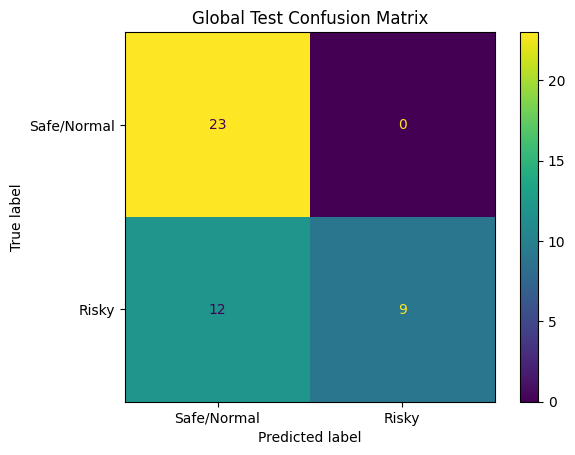

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_path = "/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/per_sequence_predictions.csv"

df = pd.read_csv(pred_path)

# Use only test sequences if the split column exists
if "split" in df.columns:
    df = df[df["split"] == "test"]

y_true = df["true_label"].astype(int)
y_pred = df["predicted_label"].astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe/Normal", "Risky"]
)

disp.plot(values_format="d")
plt.title("Global Test Confusion Matrix")
plt.show()

Confusion Matrix:
[[23  0]
 [12  9]]


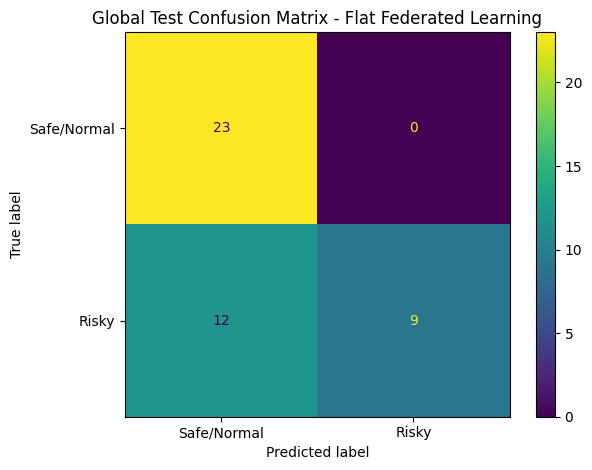

Saved confusion matrix image to:
/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/thesis_graphs/global_test_confusion_matrix.png
Saved confusion matrix CSV to:
/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/thesis_graphs/matrix_finalphase.csv


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

# Paths
pred_path = "/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/per_sequence_predictions.csv"
save_dir = "/content/drive/MyDrive/GP26-Habiba-LearningWhatMatters/Models/thesis_graphs"

os.makedirs(save_dir, exist_ok=True)

# Load predictions
df = pd.read_csv(pred_path)

# Use only test sequences if split column exists
if "split" in df.columns:
    df = df[df["split"] == "test"]

# True and predicted labels
y_true = df["true_label"].astype(int)
y_pred = df["predicted_label"].astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print("Confusion Matrix:")
print(cm)

# Save confusion matrix as CSV
cm_df = pd.DataFrame(
    cm,
    index=["Actual Safe/Normal", "Actual Risky"],
    columns=["Predicted Safe/Normal", "Predicted Risky"]
)

csv_save_path = f"{save_dir}/matrix_finalphase.csv"
cm_df.to_csv(csv_save_path)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe/Normal", "Risky"]
)

disp.plot(values_format="d")
plt.title("Global Test Confusion Matrix - Flat Federated Learning")
plt.tight_layout()

# Save figure
png_save_path = f"{save_dir}/global_test_confusion_matrix.png"
plt.savefig(png_save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix image to:")
print(png_save_path)

print("Saved confusion matrix CSV to:")
print(csv_save_path)